<a href="https://colab.research.google.com/github/belensilva1206/Agente-RAG-ley-21.719/blob/main/RAG_Leyes_PYME.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ⚖️ RAG Legal para PYMES — Framework automatizado

Pipeline: **PDFs en Drive → Markdown → chunking jerárquico (Título/Artículo/Inciso) → ChromaDB → recuperación híbrida (densa + dispersa + RRF) → reranker BGE → respuesta con citas.**

**Ejecuta las celdas en orden.** Cada bloque `C#` es independiente y guarda su salida en disco, así que puedes reanudar sin repetir todo.

| Celda | Qué hace |
|---|---|
| C0 | Instalación |
| C1 | Configuración central (edita aquí) |
| C2 | Leyes desde Drive (+ reanudación) |
| C3 | PDF → Markdown + limpieza → `/leyes_md/` |
| C4 | Parser jerárquico → chunks + informe QA |
| C4-bis | Estadística descriptiva (tablas + figuras) |
| C5 | Embeddings + ChromaDB |
| C6 | Índice disperso BM25 |
| C7 | Ruteo semántico |
| C8 | Recuperación híbrida + Fusión RRF |
| C9 | Reranker BGE |
| C10 | Generación con citas verificadas |
| C11 | Banco de pruebas PYME |

> **Runtime → Cambiar tipo de entorno → GPU T4** antes de empezar. Sin GPU funciona, pero BGE-M3 tarda ~8x más.

In [ ]:
# ═══════════════════════════════════════════════════════════════
# C0 · INSTALACIÓN
# ═══════════════════════════════════════════════════════════════
%pip -q install pymupdf4llm pypdf chromadb sentence-transformers rank_bm25 unidecode pandas matplotlib
%pip -q install FlagEmbedding        # reranker oficial BGE (si falla, C9 usa CrossEncoder)
%pip -q install anthropic openai     # solo para C10; elige uno

import torch, sys
print("Python :", sys.version.split()[0])
print("GPU    :", torch.cuda.is_available(), torch.cuda.get_device_name(0) if torch.cuda.is_available() else "")
print("\n✅ Si viste errores de dependencias arriba: Runtime → Reiniciar sesión → vuelve a correr SOLO esta celda.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.4/176.4 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.8/25.8 MB 52.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.9/42.9 MB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 395.5/395.5 kB 37.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 53.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.8/235.8 kB 25.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 24.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 81.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.6/23.6 MB 29.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.2/137.2 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6

In [ ]:
# ═══════════════════════════════════════════════════════════════
# C1 · CONFIGURACIÓN  ← ÚNICO LUGAR QUE NECESITAS EDITAR
# ═══════════════════════════════════════════════════════════════
from pathlib import Path

class CFG:
    # --- rutas ---
    DIR_BASE   = Path("/content/rag_leyes")
    DIR_PDF    = DIR_BASE / "pdf"
    DIR_MD     = DIR_BASE / "leyes_md"      # ← aquí quedan los .md
    DIR_CHUNKS = DIR_BASE / "chunks"
    DIR_CHROMA = DIR_BASE / "chroma"

    # --- modelos ---
    # BGE-M3: multilingüe, 8192 tokens, el del paper 2402.03216 de tu revisión.
    # Alternativa liviana CPU: "intfloat/multilingual-e5-small"
    EMB_MODEL      = "BAAI/bge-m3"
    RERANK_MODEL   = "BAAI/bge-reranker-v2-m3"   # multilingüe. NO uses bge-reranker-base (EN/ZH)
    # "ninguno" = por defecto. C10 solo DEFINE el prompt y la auditoría de citas;
    # quien genera de verdad es C13 con los modelos locales de Ollama.
    # Cámbialo solo si quieres comparar contra una API externa.
    # El cross-encoder trunca lo que exceda este límite y reordena leyendo
    # solo el comienzo del chunk. Con 512 se truncaba el 5% del corpus
    # (máximo observado: 988 tokens); 1024 lo cubre entero. Cuesta ~4x por
    # par —la atención es cuadrática— pero sobre 30 candidatos es trivial.
    RERANK_MAX_TOKENS = 1024
    LLM_PROVEEDOR  = "ninguno"                    # "ninguno" | "anthropic" | "openai"
    LLM_MODELO     = "claude-sonnet-4-5"          # solo si LLM_PROVEEDOR ≠ "ninguno"

    # --- chunking jerárquico ---
    INCISO_MIN_CHARS = 60      # bajo esto, y si quedó cortado, se fusiona con el siguiente
    INCISO_MAX_CHARS = 1400    # incisos más largos se sub-dividen con solapamiento
    SOLAPE_CHARS     = 150
    INDEXAR_ARTICULO_COMPLETO = True   # además del inciso, indexa el artículo entero

    # --- recuperación ---
    K_DENSA   = 25
    K_DISPERSA= 25
    RRF_K     = 60      # constante de Reciprocal Rank Fusion
    K_FINAL   = 6       # chunks que llegan al LLM tras el reranker
    UMBRAL_RERANK = 0.05  # descarta chunks con score de reranker bajo este valor

    # --- limpieza de PDF ---
    UMBRAL_BOILERPLATE = 0.6   # línea repetida en ≥60% de páginas = encabezado/pie

for d in (CFG.DIR_PDF, CFG.DIR_MD, CFG.DIR_CHUNKS, CFG.DIR_CHROMA):
    d.mkdir(parents=True, exist_ok=True)

print("📁 Estructura creada en", CFG.DIR_BASE)
for d in (CFG.DIR_PDF, CFG.DIR_MD, CFG.DIR_CHUNKS, CFG.DIR_CHROMA):
    print("   ", d)

📁 Estructura creada en /content/rag_leyes
    /content/rag_leyes/pdf
    /content/rag_leyes/leyes_md
    /content/rag_leyes/chunks
    /content/rag_leyes/chroma


In [ ]:
# ═══════════════════════════════════════════════════════════════
# C2 · LEYES DESDE GOOGLE DRIVE
# ═══════════════════════════════════════════════════════════════
import os, shutil, zipfile
from google.colab import drive

if not Path("/content/drive/MyDrive").exists():
    drive.mount("/content/drive")
MI_UNIDAD = Path("/content/drive/MyDrive")

# ─── EDITA ESTA LÍNEA ───────────────────────────────────────────
RUTA_LEYES = Path("/content/drive/MyDrive/Material tesis - Ley Protección Datos/Leyes")
# ────────────────────────────────────────────────────────────────

# respaldo del índice (ver C5-bis). Las leyes NUNCA se modifican.
DIR_RESPALDO = RUTA_LEYES.parent / "rag_indice"
DIR_RESPALDO.mkdir(parents=True, exist_ok=True)

IGNORAR = {".shortcut-targets-by-id", ".Trash", "__MACOSX"}

def buscar_carpetas_con_pdf(raiz, minimo=2, prof_max=3):
    """Si la ruta está mal, en vez de fallar en seco te la encuentra."""
    raiz = str(raiz).rstrip("/"); base = raiz.count(os.sep); out = []
    for dirpath, dirnames, filenames in os.walk(raiz):
        dirnames[:] = [d for d in dirnames
                       if d not in IGNORAR and not d.startswith(".")]
        if dirpath.count(os.sep) - base >= prof_max:
            dirnames[:] = []
        n = sum(1 for f in filenames
                if f.lower().endswith(".pdf") and not f.startswith("._"))
        if n >= minimo:
            out.append((n, dirpath))
    return sorted(out, reverse=True)

if not RUTA_LEYES.exists():
    print(f"❌ No existe: {RUTA_LEYES}\n")
    print("Carpetas de tu Drive que sí tienen PDFs:\n")
    for n, d in buscar_carpetas_con_pdf(MI_UNIDAD)[:10]:
        print(f'   {n:2} PDF  →  RUTA_LEYES = Path("{d}")')
    raise SystemExit("\n☝️  Copia la ruta correcta arriba y reejecuta la celda.")

# ZIP dentro de la carpeta (por si acaso)
for z in RUTA_LEYES.glob("*.zip"):
    print(f"📦 Descomprimiendo {z.name}")
    with zipfile.ZipFile(z) as f:
        f.extractall(CFG.DIR_PDF)

# PDFs → copiar a local. A propósito: leer desde Drive vía FUSE es lento
# y en archivos grandes puede devolver lecturas parciales.
for p in sorted(RUTA_LEYES.rglob("*.pdf")):
    if p.name.startswith("._") or "__MACOSX" in str(p):
        continue
    destino = CFG.DIR_PDF / p.name
    if not destino.exists():
        shutil.copy2(p, destino)

PDFS = sorted(p for p in CFG.DIR_PDF.glob("*.pdf") if not p.name.startswith("._"))

# --- reanudación automática ---
# Si ya indexaste antes y quedó el respaldo en Drive, se restaura acá.
# Así C5 encuentra el índice hecho y no vuelve a vectorizar.
RESPALDO = DIR_RESPALDO / "indice.zip"
if RESPALDO.exists() and not (CFG.DIR_CHROMA / "chroma.sqlite3").exists():
    print(f"♻️  Restaurando índice previo ({RESPALDO.stat().st_size/1e6:.0f} MB)…")
    shutil.unpack_archive(RESPALDO, CFG.DIR_BASE)
    print("   Listo. C3 y C4 puedes saltarlas; C5 detectará el índice.\n")

print(f"📂 Origen  : {RUTA_LEYES}")
print(f"💾 Respaldo: {DIR_RESPALDO}")
print(f"\n📄 {len(PDFS)} PDF listos en local:\n")
for p in PDFS:
    print(f"   • {p.name}  ({p.stat().st_size/1e6:.1f} MB)")
if len(PDFS) != 6:
    print(f"\n⚠️  Esperabas 6 y hay {len(PDFS)}.")

Mounted at /content/drive
📂 Origen  : /content/drive/MyDrive/Material tesis - Ley Protección Datos/Leyes
💾 Respaldo: /content/drive/MyDrive/Material tesis - Ley Protección Datos/rag_indice

📄 6 PDF listos en local:

   • DTO-100_Constitucion_Politica_Republica.pdf  (0.5 MB)
   • LEY-19628_Proteccion_Vida_Privada.pdf  (0.1 MB)
   • LEY-20285_Acceso_Informacion_Publica.pdf  (0.1 MB)
   • Ley-19496_Proteccion_Derechos_Consumidores.pdf  (0.3 MB)
   • Ley-20416_Especial_Pymes.pdf  (0.1 MB)
   • Ley-21719_Proteccion_Datos.pdf  (0.2 MB)


In [49]:
# ═══════════════════════════════════════════════════════════════
# C3 · PDF → MARKDOWN  (+ limpieza)  →  /leyes_md/
# ═══════════════════════════════════════════════════════════════
import re, json, textwrap
from collections import Counter
import pymupdf4llm

# ---------- patrones estructurales (se reutilizan en C4) ----------
P_LIBRO    = re.compile(r"^\s*#*\s*\**\s*(LIBRO\s+[IVXLCDM\dº°]+.*)$", re.I)
P_TITULO   = re.compile(r"^\s*#*\s*\**\s*(T[ÍI]TULO\s+(?:PRELIMINAR|FINAL|[IVXLCDM\d]+)\b.*)$", re.I)
P_CAPITULO = re.compile(r"^\s*#*\s*\**\s*(CAP[ÍI]TULO\s+[IVXLCDM\d]+\b.*)$", re.I)
P_PARRAFO  = re.compile(r"^\s*#*\s*\**\s*(P[ÁA]RRAFO\s+[IVXLCDM\dº°]+\b.*)$", re.I)
# Los artículos TRANSITORIOS y los de las leyes modificatorias no se numeran
# con cifras sino con ordinales escritos: "Artículo primero.- Apruébase…",
# "Artículo sexto transitorio". Sin esta alternativa quedaban absorbidos como
# incisos del último artículo numerado: el texto se recuperaba, pero con la
# CITA equivocada — y en un RAG legal la cita ES el producto. En la Ley 21.719
# eso afectaba, entre otros, al artículo sexto transitorio (atenuación de
# sanciones para PYMES durante los primeros 12 meses) y al primero transitorio
# (entrada en vigencia), las dos normas más consultables por una PYME.
ORDINAL_ESCRITO = (
    # decena opcional y separada: "Artículo décimo cuarto". Sin ella el patrón
    # cortaba en "décimo" y el cuerpo del artículo empezaba con "Cuarto.- …".
    r"(?:(?:d[ée]cim|vig[ée]sim|trig[ée]sim)[oa][ \t]+)?"
    r"(?:primer|segund|tercer|cuart|quint|sext|s[ée]ptim|octav|noven"
    r"|d[ée]cim|und[ée]cim|duod[ée]cim|vig[ée]sim|trig[ée]sim"
    r"|decimo\w+|vigesimo\w+)[oa]"
    # "Artículo transitorio.-" en singular y sin ordinal existe (Ley 20.285).
    r"|[úu]nic[oa]|final|transitori[oa]")

P_ARTICULO = re.compile(
    r"^\s*#*\s*\**\s*(Art[íi]culo|ART[ÍI]CULO|Art\.|ART\.)\s*"   # 1 — SIN re.I
    # 2=número: cifra ("7") u ordinal escrito ("primero", "sexto transitorio").
    # El ordinal lleva (?i:…) porque el encabezado puede ir en versalitas, pero
    # el grupo 1 sigue sin re.I: así "…el artículo primero de la ley N° 20.285"
    # en minúscula, que es una REFERENCIA, no crea un artículo fantasma.
    rf"(\d+|(?i:(?:{ORDINAL_ESCRITO})(?:[ \t]+transitori[oa])?))\s*"
    r"([º°]?)\s*"                                     # 3=ordinal volado
    # 4=sufijo latino (bis/ter…)  5=sufijo de LETRA (17 A, 50 B, 53 C)
    # La letra exige puntuación detrás: así "Artículo 24 A contar de…" no
    # confunde la preposición con un sufijo. Sin el grupo 5, la Ley 19.496
    # llamaba "Artículo 17" a los artículos 17 A, 17 B … 17 L: citas erradas
    # y colisión de identificadores.
    # la letra admite guion pegado ("Artículo 39-C") o espacio ("54 Ñ"),
    # e incluye Ñ, que existe en la Ley 19.496.
    # La serie latina llega hasta 'decies' en la Ley 21.719 (30 septies,
    # 30 octies, 30 nonies). Cortarla en 'sexies' hacía que los tres se
    # llamaran "Artículo 30" y colisionaran.
    r"(?:(?i:(bis|ter|qu[áa]ter|quinquies|sexies|septies|octies|nonies|decies"
    r"|undecies|duodecies|terdecies))"
    r"|[ \t]*-?[ \t]*([A-ZÑ])(?=[ \t]*[\.\-–—:]))?\s*"
    r"[\.\-–—:\)\*\s]*(.*)$")                          # 6=resto del texto
# Dos decisiones deliberadas:
#  · el separador es multi-carácter: la redacción chilena usa ".-" y el
#    markdown agrega "**" →  "**Artículo 7º.-** Contrato…"
#  · NO lleva re.I: el ENCABEZADO se escribe "Artículo"/"ARTÍCULO", mientras
#    que la REFERENCIA dentro del texto va en minúscula ("…lo dispuesto en el
#    artículo 32 N°8…"). Sin esta distinción, el preámbulo de un decreto crea
#    artículos fantasma.

def es_estructural(linea):
    return any(p.match(linea) for p in (P_LIBRO, P_TITULO, P_CAPITULO, P_PARRAFO, P_ARTICULO))

# ---------- limpieza ----------
def detectar_boilerplate(paginas, umbral, max_len=140):
    """Encabezados/pies: líneas que se repiten en muchas páginas.

    max_len=140 y no 90: el pie de la BCN mide 95 caracteres
    ("Biblioteca del Congreso Nacional de Chile - www.leychile.cl -
    documento generado el 17-Ago-2026") y con el límite anterior se
    colaba en TODAS las páginas de TODAS las leyes. Lo que protege de
    borrar texto normativo no es el largo, sino el umbral de repetición:
    un inciso no aparece idéntico en el 60% de las páginas."""
    cnt = Counter()
    for pg in paginas:
        for ln in {l.strip() for l in pg.split("\n") if l.strip()}:
            if len(ln) <= max_len:
                cnt[ln] += 1
    n = max(1, len(paginas))
    return {ln for ln, c in cnt.items()
            if c / n >= umbral and not es_estructural(ln)}

def dehifenar(txt):
    return re.sub("(\\w)[-\\u00ad]\\s*\\n\\s*(\\w)", r"\1\2", txt)

# --- notas marginales de vigencia (PDFs de la BCN) ---
# Estos PDF llevan una columna lateral con la procedencia de cada norma
# ("CPR Art. 1° D.O. 24.10.1980"). El extractor la intercala DENTRO de las
# frases: "…grupos intermedios a 24.10.1980 través de los cuales…".
# No es cosmético: corrompe el texto que se vectoriza y el que se le cita
# al usuario. Los patrones son deliberadamente estrechos para no tocar
# referencias legítimas del cuerpo ("la ley N° 19.628").
P_ANOTACION = re.compile(
    r"(?:"
    r"\bCPR\s+Art\.?\s*\d+[°º]?(?:\s*inc\.?\s*\d+)?"      # CPR Art. 1°
    r"|\b(?:LEY|DTO|DFL|DL)\s+\d{4,5}\b"                   # LEY 20050 (sin N°, sin puntos)
    r"|\bArt\.?\s*\d+\s*N[°º]\s*\d+(?=\s*D\.\s?O\.)"       # Art. 1 N° 14, pegado a D.O.
    r"|\bD\.\s?O\.\s*"                                      # D.O.
    r"|\b\d{2}\.\d{2}\.\d{4}\b"                             # 26.08.2005
    r")", re.I)

# --- notas de MODIFICACIÓN ---
# Distinto de las anteriores: la BCN marca qué numeral de la ley
# modificatoria cambió cada inciso → "Art. 1, N° 3 a)", "Art. único Nº 19".
# Dos daños: (1) "Art." abreviado matchea P_ARTICULO y crea artículos
# fantasma que se ROBAN el texto normativo siguiente; (2) intercaladas en
# una frase la parten ("…monto de las multas Art. único Nº 19 señaladas…").
# Se exige "Art." ABREVIADO + N° obligatorio: así "artículo 19 N° 4" del
# cuerpo queda intacto. Y usa [ \t] en vez de \s para NO cruzar saltos de
# línea: con \s se comía el encabezado de la línea siguiente.
P_MODIFICACION = re.compile(
    r"\bArt\.[ \t]*(?:\d+[ \t]*[°º]?|[úu]nico)[ \t]*,?[ \t]*"
    r"N[°º][ \t]*\d+[ \t]*(?:[a-z]\))?(?:[ \t]*,[ \t]*(?:[a-z]\)|i+)[ \t]*,?)*", re.I)

def quitar_anotaciones(txt):
    encontradas = P_ANOTACION.findall(txt) + P_MODIFICACION.findall(txt)
    t = P_MODIFICACION.sub(" ", txt)
    t = P_ANOTACION.sub(" ", t)
    t = re.sub(r"[ \t]{2,}", " ", t)
    t = re.sub(r"\s+([,\.;:])", r"\1", t)
    return t, len(encontradas)

# --- pie de página de la BCN ---
# Se elimina por CONTENIDO, no por frecuencia ni por largo. El detector
# de boilerplate depende de que la línea salga idéntica en muchas
# páginas, y basta con que el extractor la parta distinto para que se
# cuele en todas: así llegó "leychile" a ser uno de los 15 términos más
# frecuentes del corpus. Exige "…de Chile" para NO tocar las menciones
# normativas reales a la "Biblioteca del Congreso Nacional" que hace la
# propia Constitución.
P_PIE_BCN = re.compile(
    r"Biblioteca del Congreso Nacional de Chile[^\n]*"
    r"|Para validar,?[ \t]*acceda al sitio web[^\n]*"
    r"|www\.leychile\.cl\S*"
    r"|documento generado el[ \t]+\d{1,2}[-\s]\w+[-\s]\d{4}"
    r"|\bingrese c[óo]digo[ \t]+[A-Z0-9]{6,}", re.I)

def desmarcar(txt):
    """pymupdf4llm envuelve los epígrafes en backticks: ## `Capítulo V`.
    Con el backtick, P_CAPITULO no matchea y se pierde la jerarquía."""
    return re.sub(r"[`]+", "", txt)

def unir_lineas(txt):
    """Reune líneas partidas por el salto de línea del PDF."""
    salida = []
    for ln in txt.split("\n"):
        s = ln.strip()
        # Se une también cuando la línea siguiente abre con puntuación:
        # el PDF parte frases dejando ", noventa días después…" en su propia
        # línea, y sin esto quedan como incisos sueltos que empiezan en coma.
        if (salida and salida[-1].strip()
                and not re.search(r"[\.\:\;»\)\]]\s*$", salida[-1])
                and s and re.match(r"[a-záéíóúñü,;:\)]", s)
                and not es_estructural(s)):
            salida[-1] = salida[-1].rstrip() + " " + s
        else:
            salida.append(s)
    return "\n".join(salida)

# --- entradas de índice / tabla de contenidos ---
# Un PDF oficial suele abrir con un índice: "Artículo 1.- Del objeto ..... 3".
# Esas líneas matchean P_ARTICULO y crean artículos fantasma cuyo "cuerpo"
# son los puntos guía. Hay que eliminarlas ANTES de parsear.
P_PUNTOS_GUIA = re.compile(r"\.{4,}\s*\d{1,4}\s*$")

# Marcadores de página. "página 10 de 139" no es un número suelto, así que el
# filtro numérico no lo tocaba: quedaba INCRUSTADO a mitad de un artículo,
# partía el párrafo en dos y dejaba huérfano el final de la frase
# ("…será la | página 10 de 139 | multa que corresponda.").
P_MARCA_PAGINA = re.compile(
    r"^\s*(?:p[áa]g(?:ina)?\.?\s*\d+\s*(?:de|/)\s*\d+"
    r"|-?\s*\d{1,4}\s*-?"
    r"|\d{1,4}\s*/\s*\d{1,4})\s*$", re.I)

def es_linea_indice(linea):
    s = linea.strip()
    if P_PUNTOS_GUIA.search(s):
        return True
    m = P_ARTICULO.match(s)
    if m:
        resto = (m.group(6) or "").strip()
        # encabezado corto que termina en un número suelto = número de página
        if len(s) < 85 and re.search(r"\s\d{1,4}\s*$", s):
            return True
        if not resto and len(s) < 40:   # "Artículo 12" solo, sin texto
            return True
    return False

def limpiar(paginas, boiler):
    out = []
    for pg in paginas:
        lineas = [l for l in pg.split("\n") if l.strip() not in boiler]
        # marcadores de página: sueltos ("12", "- 42 -") y con total
        # ("página 10 de 139", "7 / 139"). Se eliminan ANTES de unir líneas
        # para que la frase que partieron vuelva a quedar completa.
        lineas = [l for l in lineas if not P_MARCA_PAGINA.match(l)]
        lineas = [l for l in lineas if not es_linea_indice(l)]
        out.append("\n".join(lineas))
    txt = "\n".join(out)
    txt = P_PIE_BCN.sub(" ", txt)
    txt = desmarcar(txt)
    txt, n_anot = quitar_anotaciones(txt)
    txt = dehifenar(txt)
    txt = unir_lineas(txt)
    txt = re.sub(r"\n{3,}", "\n\n", txt)
    txt = re.sub(r"[ \t]{2,}", " ", txt)
    return txt.strip(), n_anot

# ---------- recorte selectivo por capítulo ----------
# La Constitución completa es el 42% del corpus, y sus capítulos sobre
# Congreso, Poder Judicial o Banco Central no tienen nada que decir sobre
# datos personales: solo compiten por aparecer en la búsqueda densa.
#
# Se conservan DOS capítulos, no uno:
#   I   — Bases de la Institucionalidad. Art. 1 (dignidad), Art. 5 inc. 2
#         (deber de respetar los derechos esenciales) y sobre todo Art. 8
#         (probidad y PUBLICIDAD de los actos del Estado), que es el
#         fundamento constitucional directo de la Ley 20.285.
#   III — De los Derechos y Deberes Constitucionales. Art. 19 N°4 (vida
#         privada y protección de datos personales, tras la Ley 21.096),
#         N°5 (inviolabilidad de las comunicaciones) y N°21 (libertad de
#         emprender), que aterriza en el Estatuto PYME.
#
# La clave es el nombre del archivo; el resto de las leyes no se toca.
RECORTE_CAPITULOS = {
    "DTO-100": {"I", "III"},
}

P_CAP_NUM = re.compile(r"^\s*#*\s*\**\s*CAP[ÍI]TULO\s+([IVXLCDM]+)\b", re.I)

def recortar_capitulos(texto, capitulos):
    """Devuelve (texto_recortado, capitulos_vistos, capitulos_conservados)."""
    salida, dentro = [], False
    vistos, guardados = [], []
    for ln in texto.split("\n"):
        m = P_CAP_NUM.match(ln)
        if m:
            num = m.group(1).upper()
            vistos.append(num)
            dentro = num in capitulos
            if dentro:
                guardados.append(num)
        if dentro:
            salida.append(ln)
    return "\n".join(salida), vistos, guardados

def nombre_ley(stem):
    """Deriva un nombre legible del archivo. Ajusta si tus nombres son crípticos."""
    s = stem.replace("_", " ").replace("-", " ").strip()
    m = re.search(r"(\d{2}[\.\s]?\d{3})", s)
    if re.search(r"ley", s, re.I) and m:
        return "Ley " + m.group(1).replace(" ", ".")
    return s.title()

# ---------- conversión ----------
informe = []
for pdf in PDFS:
    paginas_raw = pymupdf4llm.to_markdown(str(pdf), page_chunks=True, show_progress=False)
    paginas = [p["text"] for p in paginas_raw]

    chars_pag = sum(len(p) for p in paginas) / max(1, len(paginas))
    boiler = detectar_boilerplate(paginas, CFG.UMBRAL_BOILERPLATE)
    texto, n_anot = limpiar(paginas, boiler)

    # --- recorte por capítulo, si este archivo está configurado ---
    recorte = next((caps for clave, caps in RECORTE_CAPITULOS.items()
                    if clave.lower() in pdf.stem.lower()), None)
    chars_antes = len(texto)
    if recorte:
        cortado, vistos, guardados = recortar_capitulos(texto, recorte)
        if len(cortado) < 500:
            # red de seguridad: si no encontró los capítulos, NO dejes el
            # archivo vacío. Mejor indexar de más que perder la norma entera.
            print(f"   ⛔ Recorte abortado: solo {len(cortado)} chars. "
                  f"Capítulos hallados: {vistos[:12]}")
            print(f"      Revisa cómo se escriben en el .md y ajusta RECORTE_CAPITULOS.")
        else:
            texto = cortado

    ley = nombre_ley(pdf.stem)
    destino = CFG.DIR_MD / f"{pdf.stem}.md"
    destino.write_text(f"# {ley}\n\n_Fuente: {pdf.name}_\n\n{texto}", encoding="utf-8")

    n_art = len([1 for l in texto.split("\n") if P_ARTICULO.match(l.strip())])
    informe.append(dict(archivo=pdf.name, ley=ley, paginas=len(paginas),
                        chars=len(texto), chars_por_pagina=round(chars_pag),
                        articulos=n_art, boilerplate=len(boiler),
                        notas_marginales=n_anot))

    print(f"✅ {pdf.name}")
    print(f"   → {destino.name} · {len(paginas)} pág · {len(texto):,} chars · {n_art} artículos detectados")
    if boiler:
        muestra = list(boiler)[:3]
        print(f"   🧹 {len(boiler)} líneas de encabezado/pie eliminadas. Ej: {muestra}")
    if n_anot:
        print(f"   ✂️  {n_anot:,} notas marginales de vigencia removidas del cuerpo del texto")
    if recorte and len(texto) < chars_antes:
        print(f"   ✂️  Recortado a capítulos {sorted(guardados)} de {len(vistos)} totales: "
              f"{chars_antes:,} → {len(texto):,} chars "
              f"(−{100*(1-len(texto)/chars_antes):.0f}%)")
    if chars_pag < 200:
        print("   ⛔ MUY POCO TEXTO → el PDF parece escaneado. Necesitas OCR:")
        print("      !apt-get -qq install ocrmypdf && ocrmypdf -l spa in.pdf out.pdf")
    if n_art == 0:
        print("   ⚠️  0 artículos detectados → revisa el .md y ajusta P_ARTICULO en esta celda.")
    print()

import pandas as pd
df_informe = pd.DataFrame(informe)
print("═" * 70)
display(df_informe)
print(f"\n📂 Markdown guardado en: {CFG.DIR_MD}")


=== Document parser messages ===
Using Tesseract for OCR processing.
OCR on page.number=0/1.
OCR on page.number=1/2.
OCR on page.number=2/3.
OCR on page.number=3/4.
OCR on page.number=4/5.
OCR on page.number=5/6.
OCR on page.number=6/7.
OCR on page.number=7/8.
OCR on page.number=8/9.
OCR on page.number=9/10.
OCR on page.number=10/11.
OCR on page.number=11/12.
OCR on page.number=12/13.
OCR on page.number=13/14.
OCR on page.number=14/15.
OCR on page.number=15/16.
OCR on page.number=16/17.
OCR on page.number=17/18.
OCR on page.number=18/19.
OCR on page.number=19/20.
OCR on page.number=20/21.
OCR on page.number=21/22.
OCR on page.number=22/23.
OCR on page.number=23/24.
OCR on page.number=24/25.
OCR on page.number=25/26.
OCR on page.number=26/27.
OCR on page.number=27/28.
OCR on page.number=28/29.
OCR on page.number=29/30.
OCR on page.number=30/31.
OCR on page.number=31/32.
OCR on page.number=32/33.
OCR on page.number=33/34.
OCR on page.number=34/35.
OCR on page.number=35/36.
OCR on page.n

,archivo,ley,paginas,chars,chars_por_pagina,articulos,boilerplate,notas_marginales
0,DTO-100_Constitucion_Politica_Republica.pdf,Dto 100 Constitucion Politica Republica,139,38964,3466,14,4,1740
1,LEY-19628_Proteccion_Vida_Privada.pdf,Ley 19628,13,32033,2884,27,5,36
2,LEY-20285_Acceso_Informacion_Publica.pdf,Ley 20285,22,70572,3644,66,5,2
3,Ley-19496_Proteccion_Derechos_Consumidores.pdf,Ley 19496,83,209200,3087,148,5,671
4,Ley-20416_Especial_Pymes.pdf,Ley 20416,25,78474,3567,53,4,2
5,Ley-21719_Proteccion_Datos.pdf,Ley 21719,56,157111,3233,87,4,34



📂 Markdown guardado en: /content/rag_leyes/leyes_md


In [50]:
# ═══════════════════════════════════════════════════════════════
# C4 · PARSER JERÁRQUICO → CHUNKS (Título · Artículo · Inciso)
# ═══════════════════════════════════════════════════════════════
import re, json, unicodedata, textwrap

def parsear_ley(md_texto, ley, archivo):
    """Recorre el markdown manteniendo el contexto jerárquico vigente."""
    ctx = dict(libro="", titulo="", capitulo="", parrafo="")
    articulos, actual = [], None
    esperando_epigrafe = None   # "titulo" | "capitulo" | ... tras un encabezado

    def cerrar():
        nonlocal actual
        if actual and actual["buf"]:
            cuerpo = "\n".join(actual["buf"]).strip()
            if cuerpo:
                actual["cuerpo"] = cuerpo
                articulos.append(actual)
        actual = None

    for raw in md_texto.split("\n"):
        ln = raw.strip()
        if not ln:
            if actual:
                actual["buf"].append("")
            continue

        if m := P_LIBRO.match(ln):
            cerrar(); ctx.update(libro=m.group(1).strip(), titulo="", capitulo="", parrafo="")
            esperando_epigrafe = "libro"; continue
        if m := P_TITULO.match(ln):
            cerrar(); ctx.update(titulo=m.group(1).strip(), capitulo="", parrafo="")
            esperando_epigrafe = "titulo"; continue
        if m := P_CAPITULO.match(ln):
            cerrar(); ctx.update(capitulo=m.group(1).strip(), parrafo="")
            esperando_epigrafe = "capitulo"; continue
        if m := P_PARRAFO.match(ln):
            cerrar(); ctx.update(parrafo=m.group(1).strip())
            esperando_epigrafe = "parrafo"; continue

        if m := P_ARTICULO.match(ln):
            cerrar(); esperando_epigrafe = None
            num, ordinal = m.group(2), (m.group(3) or "")
            # "bis" va en minúscula; la letra en mayúscula ("Artículo 17 A").
            # El resto del texto es el grupo 6, NO el 5: el 5 es el sufijo
            # de letra. Leer el 5 deja el cuerpo vacío y hace que cada
            # artículo pierda el texto de su línea de encabezado — en el
            # art. 7° de la Ley 21.719 eso borraba "Derecho de supresión.
            # El titular tiene derecho a solicitar y obtener la eliminación…"
            # y dejaba solo las condiciones a) b) c) sin decir de qué son.
            sufijo = (m.group(4) or "").lower() or (m.group(5) or "").upper()
            resto = (m.group(6) or "").strip().strip("*").strip()
            etiqueta = f"Artículo {num}{ordinal}" + (f" {sufijo}" if sufijo else "")
            actual = dict(ley=ley, archivo=archivo, **ctx,
                          articulo_num=num, articulo_sufijo=sufijo,
                          articulo_label=etiqueta, buf=[resto] if resto else [])
            continue

        # epígrafe: la línea descriptiva que sigue a "TÍTULO II" ("DEL CONTRATO…")
        if esperando_epigrafe and len(ln) < 90 and not actual:
            limpio = ln.lstrip("#* ").strip()
            if limpio:
                ctx[esperando_epigrafe] = f"{ctx[esperando_epigrafe]} — {limpio}"
            esperando_epigrafe = None
            continue
        esperando_epigrafe = None

        # Un titulillo de la BCN ("## Ministros de Estado") nunca es texto
        # normativo. Si se deja, se fusiona con el artículo que lo precede
        # y puede arrastrarlo entero al filtro de epígrafes.
        if re.match(r"^#{1,6}\s", ln):
            continue

        if actual:
            actual["buf"].append(ln)

    cerrar()
    return articulos

# una enumeración pertenece al inciso que la introduce: separarla rompe el sentido.
# {1,3} en el separador: la redacción chilena numera "1.-", "4°.-", no solo "1.".
# Sin eso, "4°.- El respeto y protección a la vida privada" (art. 19 N°4 CPR)
# no se pegaba a su encabezado, quedaba suelto y lo descartaba es_epigrafe.
P_ENUMERACION = re.compile(r"^\s*(?:[a-zñ]\)|\d+\s*[\)\.\-º°]{1,3}|[ivxl]+\)|[-–—•])\s", re.I)

def _completo(t):
    """¿El bloque parece un inciso terminado, o quedó cortado por el PDF?"""
    return len(t) >= CFG.INCISO_MIN_CHARS and bool(re.search(r"[\.\:\;»]\s*$", t))

def es_epigrafe(t):
    """Los PDF de la BCN llevan titulillos en el margen ("Ministros de
    Estado", "Estados de excepción constitucional") que el extractor deja
    sueltos y terminan como chunks sin contenido normativo.
    Un artículo real termina en punto; un titulillo no."""
    s = re.sub(r"^[#\s]+", "", t.strip()).strip()
    if len(s) < 25:
        return True
    # titulillo con el número de página pegado: "Gobierno y Administración
    # Regional 49." — el punto final lo disfrazaba de oración completa.
    # Pero una frase legítima también puede cerrar en número ("…en vigencia
    # el 1 de diciembre de 2026."). Los distingue la palabra anterior: en la
    # frase real es una preposición o un sustantivo de referencia; en el
    # titulillo, el número cuelga suelto del título.
    ANTES_DE_NUMERO = {"de", "del", "al", "en", "desde", "hasta", "n°", "nº", "no",
                       "ley", "artículo", "articulo", "inciso", "letra", "número",
                       "numero", "año", "fecha", "enero", "febrero", "marzo",
                       "abril", "mayo", "junio", "julio", "agosto", "septiembre",
                       "octubre", "noviembre", "diciembre"}
    m = re.search(r"(\S+)\s+\d{1,4}\.?\s*$", s)
    if len(s) < 70 and m and m.group(1).lower().strip(".,;:") not in ANTES_DE_NUMERO:
        return True
    if len(s) < 60 and not re.search(r"[\.;:]\s*$", s):
        return True
    return False

def partir_incisos(cuerpo):
    """Un inciso = bloque separado por línea en blanco, con dos salvedades:
       1. las enumeraciones a)/1) se pegan al bloque que las encabeza;
       2. solo se fusiona lo que parece CORTADO, no todo lo que es corto.

    Devuelve (incisos, n_titulillos_descartados). El segundo valor cuenta
    SOLO lo eliminado: las fusiones de los pasos 1 y 2 no son pérdida de
    contenido y contarlas como descarte da una cifra alarmista y falsa."""
    bloques = [b.strip() for b in re.split(r"\n\s*\n", cuerpo) if b.strip()]
    if not bloques:
        return [], 0

    # 1 · enumeraciones hacia atrás
    unidos = []
    for b in bloques:
        if unidos and (P_ENUMERACION.match(b) or unidos[-1].rstrip().endswith(":")):
            unidos[-1] += "\n" + b
        else:
            unidos.append(b)

    # 1b · los titulillos se eliminan ANTES de fusionar. Si se filtran
    # después, uno corto ("Gobierno y Administración Regional 49.") ya se
    # fusionó con el artículo real que lo precede y lo contamina.
    antes = len(unidos)
    unidos = [b for b in unidos if not es_epigrafe(b)]
    n_tit = antes - len(unidos)
    if not unidos:
        return [], n_tit

    # 2 · fusión conservadora de fragmentos truncados
    fusionados = []
    for b in unidos:
        if fusionados and not _completo(fusionados[-1]):
            fusionados[-1] += "\n" + b
        else:
            fusionados.append(b)

    # 3 · sub-dividir bloques enormes, cortando en fin de oración
    final = []
    for b in fusionados:
        if len(b) <= CFG.INCISO_MAX_CHARS:
            final.append(b); continue
        oraciones = re.split(r"(?<=[\.\;])\s+", b)
        acc = ""
        for o in oraciones:
            if len(acc) + len(o) + 1 > CFG.INCISO_MAX_CHARS and acc:
                final.append(acc.strip())
                acc = acc[-CFG.SOLAPE_CHARS:] + " " + o   # solapamiento
            else:
                acc = (acc + " " + o).strip()
        if acc.strip():
            final.append(acc.strip())
    return final, n_tit

def texto_contextual(ch):
    """Antepone la jerarquía al texto: mejora mucho la recuperación."""
    partes = [ch["ley"]]
    for k in ("titulo", "capitulo", "parrafo"):
        if ch.get(k):
            partes.append(ch[k])
    partes.append(ch["articulo_label"])
    if ch["tipo"] == "inciso":
        partes.append(f"inciso {ch['inciso_num']}")
    return " — ".join(partes) + "\n" + ch["texto"]

def cita_de(ch):
    c = f"{ch['ley']}, {ch['articulo_label']}"
    if ch["tipo"] == "inciso":
        c += f", inciso {ch['inciso_num']}"
    return c

# ---------- construir todos los chunks ----------
CHUNKS, ARTICULOS_FULL = [], {}
orden = 0
n_descartados = n_fusionados = 0
vistos_art, COLISIONES = {}, []

for md_file in sorted(CFG.DIR_MD.glob("*.md")):
    texto = md_file.read_text(encoding="utf-8")
    ley = texto.split("\n")[0].lstrip("# ").strip()
    arts = parsear_ley(texto, ley, md_file.stem)

    for a in arts:
        # --- articulo_id ÚNICO ---
        # Una misma ley puede repetir el número de artículo (articulado
        # permanente vs transitorio, o normas que transcriben artículos que
        # insertan en otra ley). Si el id colisiona, también colisiona el
        # chunk_id, y COL.add() en C5 SOBRESCRIBE sin avisar: se pierden
        # chunks en silencio. El sufijo __r2 los mantiene separados.
        base_id = f"{md_file.stem}__art_{a['articulo_num']}{a['articulo_sufijo']}"
        rep = vistos_art.get(base_id, 0) + 1
        vistos_art[base_id] = rep
        art_id = base_id if rep == 1 else f"{base_id}__r{rep}"

        etiqueta = a["articulo_label"]
        if rep > 1:
            COLISIONES.append(dict(ley=ley[:30], articulo=etiqueta, aparicion=rep,
                                   contexto=(a["titulo"] or a["capitulo"] or "—")[:40],
                                   inicio=a["cuerpo"][:70]))
            # la cita debe distinguirlos para el usuario, no solo el id
            ctx = a["capitulo"] or a["titulo"]
            if ctx:
                etiqueta = f"{etiqueta} ({ctx[:38]})"

        ARTICULOS_FULL[art_id] = dict(cita=f"{ley}, {etiqueta}", texto=a["cuerpo"])

        base = {k: a[k] for k in ("ley", "archivo", "libro", "titulo", "capitulo",
                                   "parrafo", "articulo_num")}
        base["articulo_label"] = etiqueta
        base["articulo_id"] = art_id

        brutos = len([b for b in re.split(r"\n\s*\n", a["cuerpo"]) if b.strip()])
        incisos, n_tit = partir_incisos(a["cuerpo"])
        n_descartados += n_tit
        n_fusionados += max(0, brutos - len(incisos) - n_tit)
        if not incisos:
            continue
        for i, inc in enumerate(incisos, 1):
            orden += 1
            ch = dict(base, chunk_id=f"{art_id}__inc_{i}", tipo="inciso",
                      inciso_num=i, texto=inc, orden=orden)
            ch["cita"] = cita_de(ch)
            ch["texto_embed"] = texto_contextual(ch)
            CHUNKS.append(ch)

        if CFG.INDEXAR_ARTICULO_COMPLETO and len(incisos) > 1:
            orden += 1
            ch = dict(base, chunk_id=f"{art_id}__full", tipo="articulo",
                      inciso_num=0, texto=a["cuerpo"][:4000], orden=orden)
            ch["cita"] = cita_de(ch)
            ch["texto_embed"] = texto_contextual(ch)
            CHUNKS.append(ch)

# ---------- persistir ----------
(CFG.DIR_CHUNKS / "chunks.json").write_text(
    json.dumps(CHUNKS, ensure_ascii=False, indent=1), encoding="utf-8")
(CFG.DIR_CHUNKS / "articulos.json").write_text(
    json.dumps(ARTICULOS_FULL, ensure_ascii=False, indent=1), encoding="utf-8")

# ---------- informe QA ----------
import pandas as pd
dfc = pd.DataFrame(CHUNKS)
print(f"📊 {len(CHUNKS):,} chunks · {len(ARTICULOS_FULL):,} artículos")
if n_fusionados:
    print(f"   🔗 {n_fusionados} bloques FUSIONADOS (enumeraciones y frases cortadas) — no es pérdida")
if n_descartados:
    print(f"   🗑️  {n_descartados} titulillos DESCARTADOS por no tener contenido normativo")
print()
print("Chunks por ley:")
display(dfc.groupby(["ley", "tipo"]).size().unstack(fill_value=0))
print("\nLargo de chunk (chars):")
display(dfc["texto"].str.len().describe().round(0).to_frame("chars"))

sospechosos = dfc[dfc["texto"].str.len() < 60]
if len(sospechosos):
    print(f"\n⚠️  {len(sospechosos)} chunks muy cortos (posible ruido de extracción):")
    display(sospechosos[["cita", "texto"]].head(5))

import collections
print("\n" + "═"*70 + "\n🔍 INTEGRIDAD DE IDENTIFICADORES\n" + "═"*70)

# 1 · chunk_id irrepetible. Es la garantía de que ChromaDB no sobrescriba.
dup_ids = [i for i, c in collections.Counter(dfc["chunk_id"]).items() if c > 1]
print(f"  chunk_id únicos : {dfc['chunk_id'].nunique():,} / {len(dfc):,} "
      f"{'✅' if not dup_ids else '❌ ' + str(dup_ids[:5])}")

# 2 · artículos cuyo número se repite dentro de la misma ley
if COLISIONES:
    print(f"\n  ℹ️  {len(COLISIONES)} artículos con número repetido en su propia ley.")
    print("     Se les dio un id distinto y se les agregó el contexto a la cita,")
    print("     así que NO se pisan. Revisa que sean artículos realmente distintos:")
    display(pd.DataFrame(COLISIONES))
else:
    print("  números de artículo repetidos: ninguno ✅")

print("\n" + "═" * 70 + "\n🔎 MUESTRA — revisa que la jerarquía esté bien capturada:\n")
for ch in CHUNKS[:3]:
    print(f"[{ch['cita']}]")
    print(f"  contexto: {ch['titulo']} | {ch['capitulo']}")
    print(f"  texto   : {ch['texto'][:220]}…\n")

📊 1,396 chunks · 395 artículos
   🔗 624 bloques FUSIONADOS (enumeraciones y frases cortadas) — no es pérdida
   🗑️  61 titulillos DESCARTADOS por no tener contenido normativo

Chunks por ley:


tipo,articulo,inciso
ley,,
Dto 100 Constitucion Politica Republica,8,70
Ley 19496,77,374
Ley 19628,15,56
Ley 20285,41,154
Ley 20416,41,196
Ley 21719,73,291



Largo de chunk (chars):


,chars
count,1396.0
mean,701.0
std,710.0
min,35.0
25%,264.0
50%,450.0
75%,912.0
max,4000.0



⚠️  3 chunks muy cortos (posible ruido de extracción):


,cita,texto
5,"Dto 100 Constitucion Politica Republica, Artíc...",Chile es una república democrática.
323,"Ley 20285, Artículo undécimo, inciso 1",Derógase el artículo 8º del decreto ley Nº 488...
1039,"Ley 21719, Artículo 5º, inciso 3",cuando una ley disponga expresamente lo contra...



══════════════════════════════════════════════════════════════════════
🔍 INTEGRIDAD DE IDENTIFICADORES
══════════════════════════════════════════════════════════════════════
  chunk_id únicos : 1,396 / 1,396 ✅

  ℹ️  25 artículos con número repetido en su propia ley.
     Se les dio un id distinto y se les agregó el contexto a la cita,
     así que NO se pisan. Revisa que sean artículos realmente distintos:


,ley,articulo,aparicion,contexto,inicio
0,Ley 19628,Artículo 1°,2,Título Final,"Las disposiciones de esta ley, con excepción d..."
1,Ley 19628,Artículo 2°,2,Título Final,Los titulares de los datos personales registra...
2,Ley 19628,Artículo 3°,2,Título Final,Las normas que regulan el Boletín de\nInformac...
3,Ley 20285,Artículo 1°,2,TÍTULO VII — Disposiciones Transitorias,De conformidad a la disposición cuarta transit...
4,Ley 20285,Artículo 2º,2,TÍTULO VII — Disposiciones Transitorias,La primera designación de consejeros del Conse...
5,Ley 20285,Artículo 3º,2,TÍTULO VII — Disposiciones Transitorias,El mayor gasto que represente la aplicación de...
6,Ley 19496,Artículo 1º,2,Titulo final,La presente ley entrará en vigencia noventa dí...
7,Ley 19496,Artículo 2º,2,Titulo final,"Derógase la ley Nº 18.223, con excepción\n\nde..."
8,Ley 19496,Artículo 3º,2,Titulo final,Las organizaciones de consumidores existentes ...
9,Ley 19496,Artículo 4º,2,Titulo final,Las normas establecidas en el artículo 17 de l...



══════════════════════════════════════════════════════════════════════
🔎 MUESTRA — revisa que la jerarquía esté bien capturada:

[Dto 100 Constitucion Politica Republica, Artículo 1°, inciso 1]
  contexto:  | Capítulo I — BASES DE LA INSTITUCIONALIDAD
  texto   : Las personas nacen libres e iguales en dignidad y derechos.
La familia es el núcleo fundamental de la sociedad. El Estado reconoce y ampara a los grupos intermedios a través de los cuales se organiza y estructura la soci…

[Dto 100 Constitucion Politica Republica, Artículo 1°, inciso 2]
  contexto:  | Capítulo I — BASES DE LA INSTITUCIONALIDAD
  texto   : Es deber del Estado resguardar la seguridad nacional, dar protección a la población y a la familia, propender al fortalecimiento de ésta, promover la integración armónica de todos los sectores de la Nación y asegurar el …

[Dto 100 Constitucion Politica Republica, Artículo 1°]
  contexto:  | Capítulo I — BASES DE LA INSTITUCIONALIDAD
  texto   : Las personas nacen libres e i

⏳ Tokenizador de BAAI/bge-m3 …


[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (8534 > 8192). Running this sequence through the model will result in indexing errors



══════════════════════════════════════════════════════════════════════════════
TABLA 1 · Composición del corpus por norma
══════════════════════════════════════════════════════════════════════════════


,Ley,Archivo,Caracteres,Palabras,Tokens,Artículos,Chunks,Títulos,Capítulos
3,Ley 19496,Ley-19496_Proteccion_Derecho,"209,271","32,875","44,695",147,451,4,0
5,Ley 21719,Ley-21719_Proteccion_Datos,"157,166","24,010","32,697",87,364,2,0
4,Ley 20416,Ley-20416_Especial_Pymes,"78,527","12,076","17,046",53,237,0,0
2,Ley 20285,LEY-20285_Acceso_Informacion,"70,637","11,166","15,488",66,195,7,0
0,Dto 100 Constitucion Politica Republica,DTO-100_Constitucion_Politic,"39,062","6,168","8,534",14,78,0,2
1,Ley 19628,LEY-19628_Proteccion_Vida_Pr,"32,095","4,992","6,902",27,71,7,0
TOTAL,TOTAL,,"586,758","91,287","125,362",394,"1,396",20,2



⏳ Tokenizando chunks …

══════════════════════════════════════════════════════════════════════════════
TABLA 2 · Distribución de longitud de los chunks
══════════════════════════════════════════════════════════════════════════════


...

,n,media,mediana,máx
tipo,,,,
articulo,255,374.0,294.0,1176
inciso,1141,129.3,105.0,485



══════════════════════════════════════════════════════════════════════════════
⚠️  TRUNCAMIENTO
══════════════════════════════════════════════════════════════════════════════
  Chunks > 8,192 tokens (embeddings BGE-M3) :     0  ✅ ninguno se corta
  Chunks > 1,024 tokens (reranker)          :     1  (0.1%)  ⚠️  el reranker solo lee su inicio
  Peor caso de contexto al LLM (K_FINAL=6) : 5,815 tokens

Qué hacer: el cross-encoder trunca a 1024 tokens, así que
1 chunks se reordenan leyendo solo su comienzo. O bajas
INCISO_MAX_CHARS en C1, o subes max_length en C9. Repórtalo:
es una limitación real de la configuración, no un detalle.

══════════════════════════════════════════════════════════════════════════════
TABLA 3 · Riqueza léxica
══════════════════════════════════════════════════════════════════════════════


,Valor
Métrica,
Tokens léxicos (ocurrencias),"150,798"
Tipos (vocabulario único),"6,103"
Razón tipo/token (TTR),0.0405
Hapax legómena,613
% hapax sobre vocabulario,10.3%



15 términos de contenido más frecuentes:


Término,datos,artículo,caso,deberá,podrá,inciso,servicio,información,personales,consumidor,tratamiento,plazo,responsable,agencia,normas
Frecuencia,1106,943,544,543,533,454,451,449,440,409,404,373,335,303,302


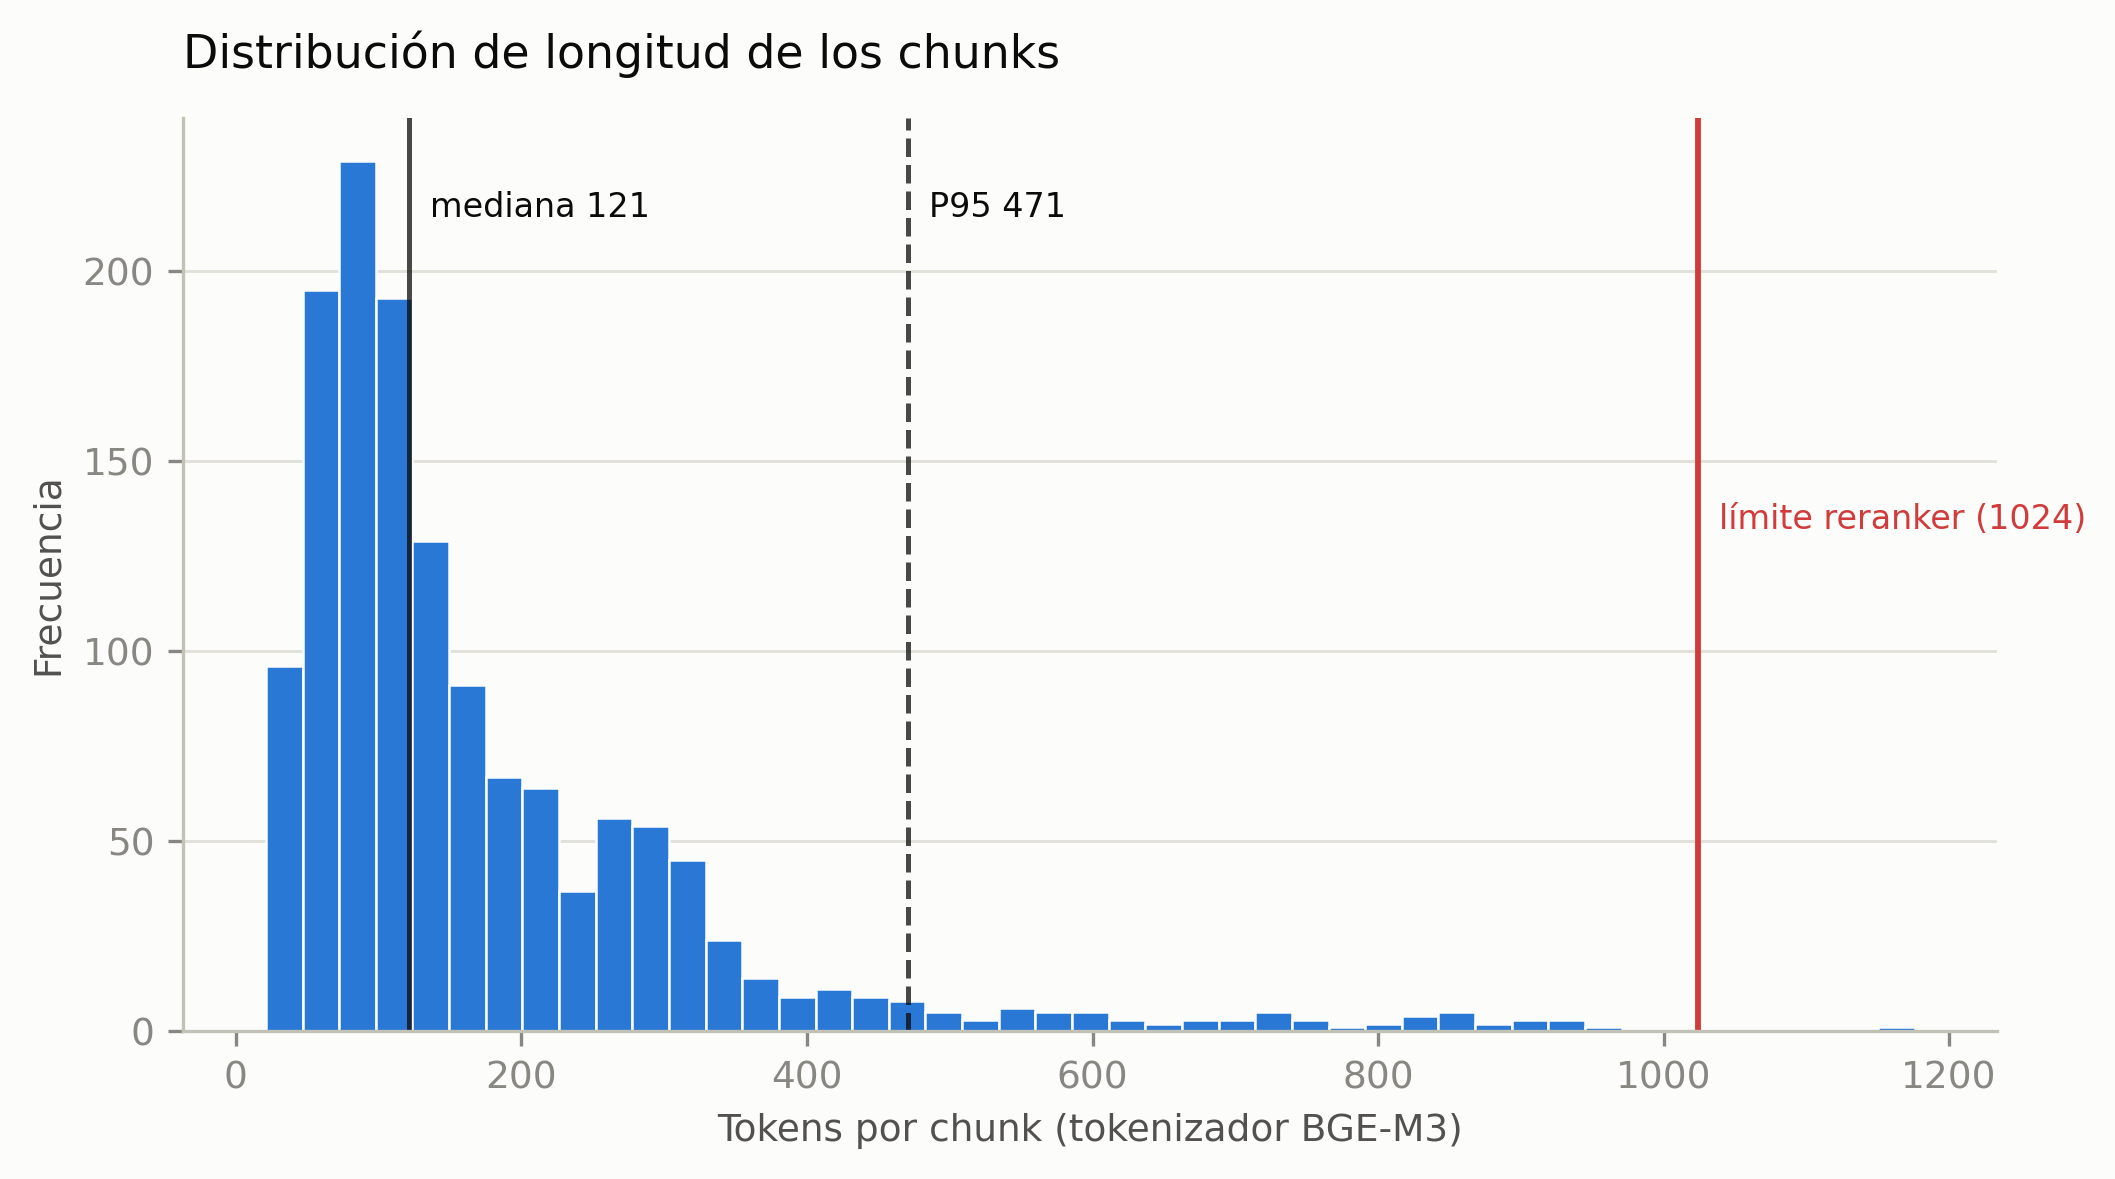

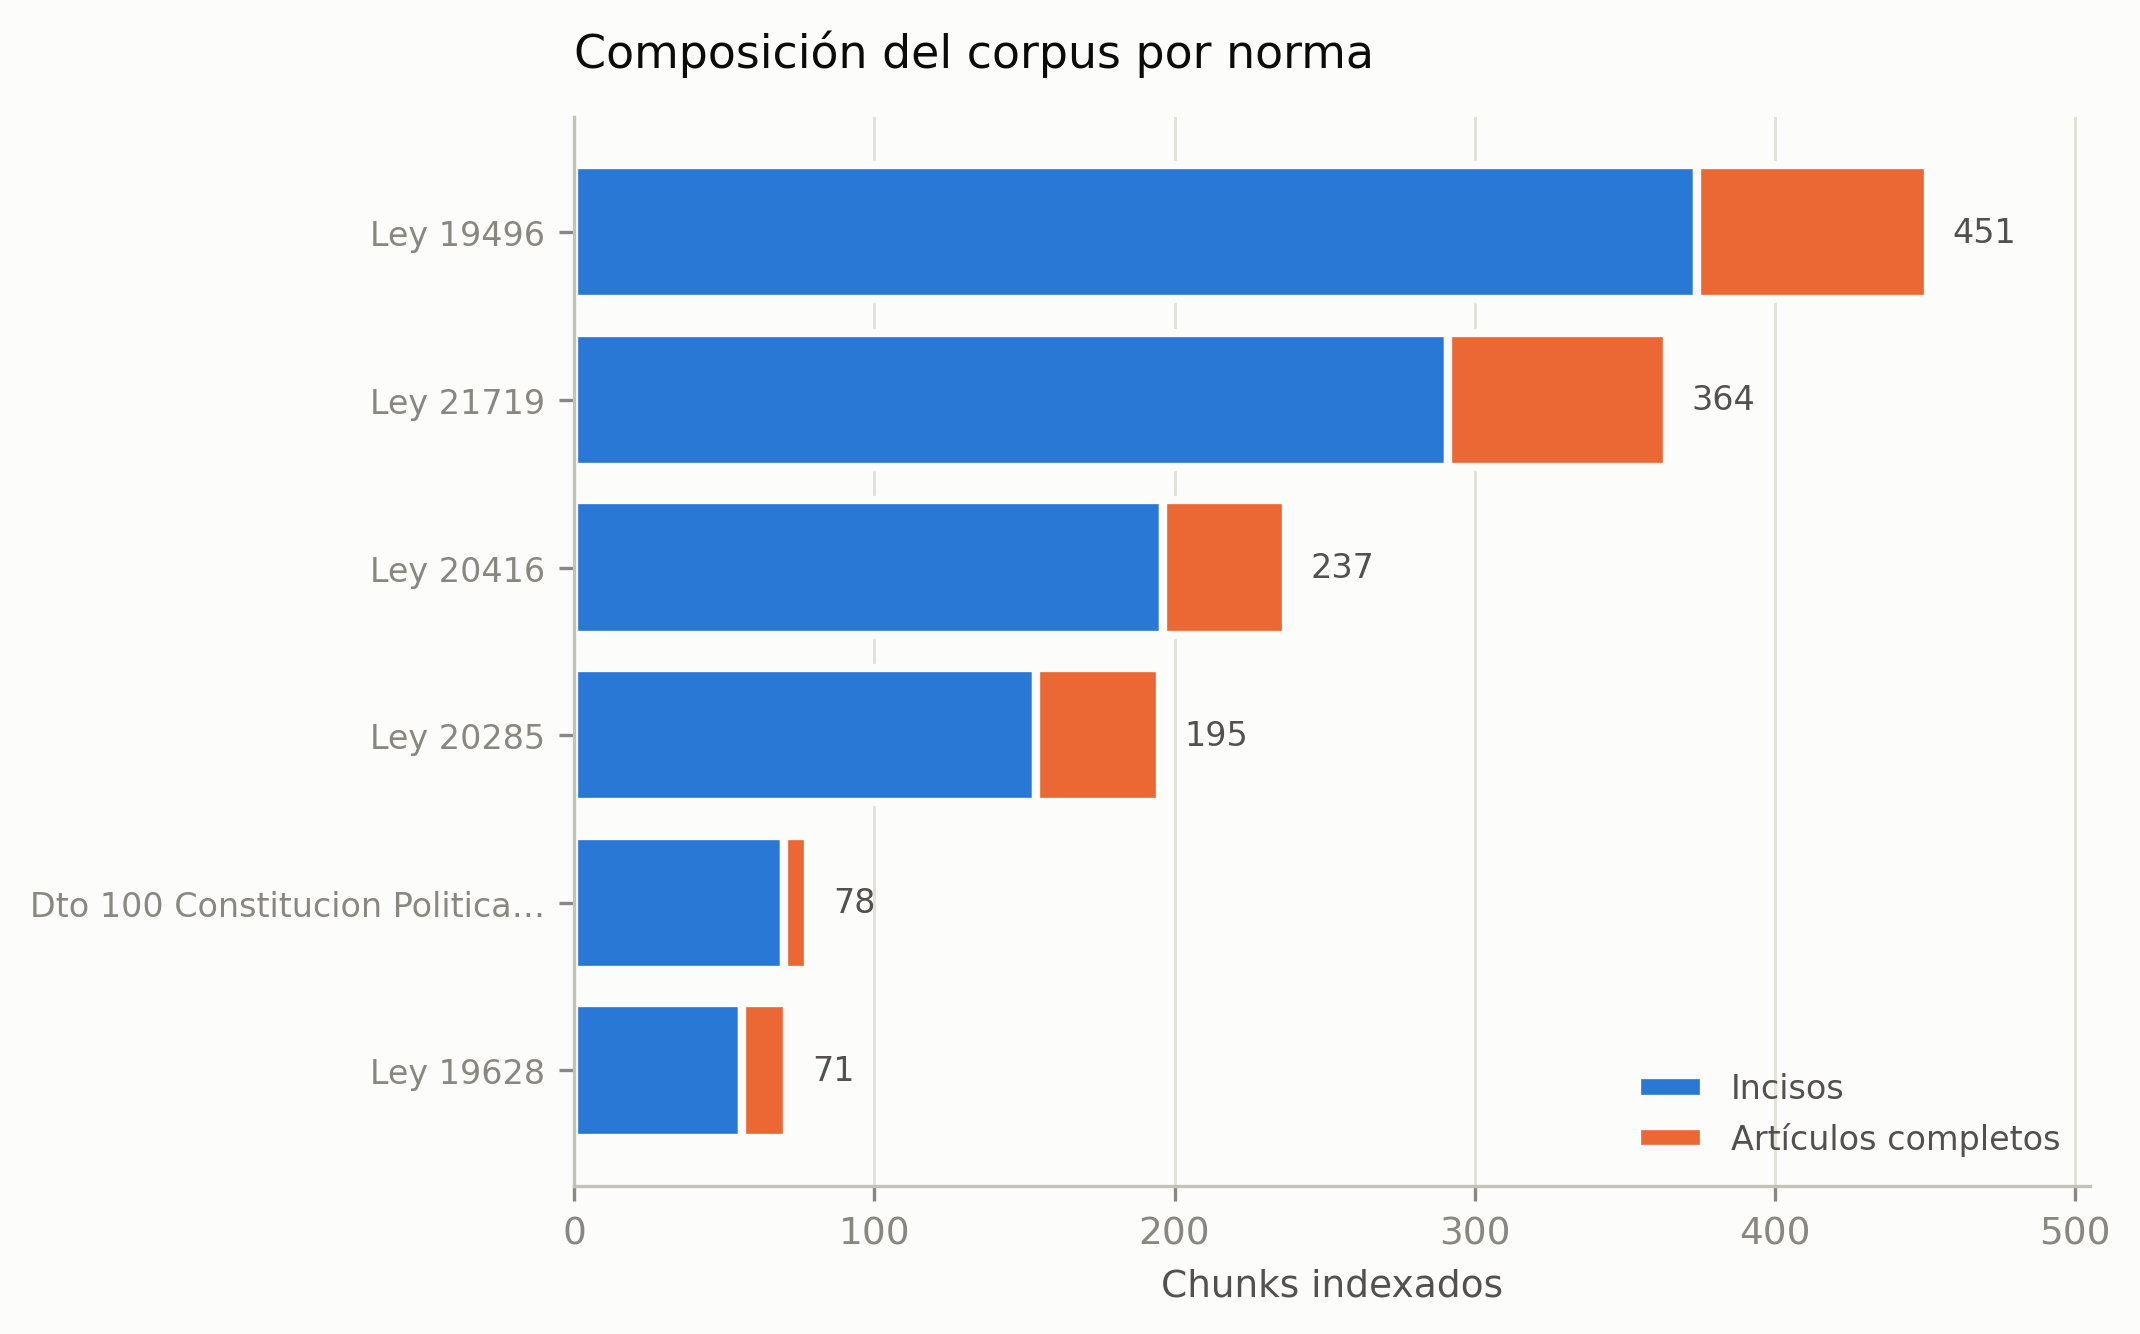


💾 Tablas (.csv + .tex) y figuras (300 dpi) en:
   /content/rag_leyes/estadisticas
   Las figuras están listas para insertar en el documento de tesis.


In [51]:
# ═══════════════════════════════════════════════════════════════
# C4-bis · ESTADÍSTICA DESCRIPTIVA DEL CORPUS
# ═══════════════════════════════════════════════════════════════
# Genera las tablas y figuras del capítulo "caracterización del corpus".
# No es solo descriptivo: los conteos de tokens detectan truncamiento
# silencioso, que es un error de sistema, no una curiosidad estadística.

import json, re, collections, textwrap
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from transformers import AutoTokenizer

DIR_STATS = CFG.DIR_BASE / "estadisticas"
DIR_STATS.mkdir(exist_ok=True)

CHUNKS = json.loads((CFG.DIR_CHUNKS / "chunks.json").read_text(encoding="utf-8"))
ARTICULOS_FULL = json.loads((CFG.DIR_CHUNKS / "articulos.json").read_text(encoding="utf-8"))

# ── tokenizador REAL del modelo ──────────────────────────────────────
# Contar con .split() da un número que no le sirve a nadie. Lo que
# importa es cómo segmenta BGE-M3 (SentencePiece de XLM-RoBERTa),
# porque es lo que define si un chunk entra completo o se corta.
print(f"⏳ Tokenizador de {CFG.EMB_MODEL} …")
TOK = AutoTokenizer.from_pretrained(CFG.EMB_MODEL)
n_tok = lambda t: len(TOK.encode(t, add_special_tokens=False))
LIM_EMB = 8192
LIM_RERANK = getattr(CFG, 'RERANK_MAX_TOKENS', 512)

# ═════════════ TABLA 1 · nivel documento ═════════════
filas_doc = []
for md_file in sorted(CFG.DIR_MD.glob("*.md")):
    txt = md_file.read_text(encoding="utf-8")
    ley = txt.split("\n")[0].lstrip("# ").strip()
    chs = [c for c in CHUNKS if c["ley"] == ley]
    arts = {c["articulo_id"] for c in chs}
    filas_doc.append(dict(
        Ley=ley, Archivo=md_file.stem[:28],
        Caracteres=len(txt), Palabras=len(txt.split()), Tokens=n_tok(txt),
        Artículos=len(arts), Chunks=len(chs),
        Títulos=len({c["titulo"] for c in chs if c["titulo"]}),
        Capítulos=len({c["capitulo"] for c in chs if c["capitulo"]}),
    ))

t1 = pd.DataFrame(filas_doc).sort_values("Tokens", ascending=False)
t1.loc["TOTAL"] = t1.sum(numeric_only=True)
t1.loc["TOTAL", ["Ley", "Archivo"]] = ["TOTAL", ""]

print("\n" + "═"*78 + "\nTABLA 1 · Composición del corpus por norma\n" + "═"*78)
display(t1.style.format({c: "{:,.0f}" for c in t1.select_dtypes("number").columns}))

# ═════════════ TABLA 2 · nivel chunk ═════════════
dfc = pd.DataFrame(CHUNKS)
dfc["chars"]  = dfc["texto"].str.len()
print("\n⏳ Tokenizando chunks …")
dfc["tokens"] = [n_tok(t) for t in dfc["texto_embed"]]   # lo que ve el modelo
dfc["palabras"] = dfc["texto"].str.split().str.len()

def describir(s):
    return pd.Series({
        "n": len(s), "media": s.mean(), "desv. est.": s.std(),
        "mín": s.min(), "P25": s.quantile(.25), "mediana": s.median(),
        "P75": s.quantile(.75), "P95": s.quantile(.95), "máx": s.max()})

t2 = pd.DataFrame({
    "Caracteres": describir(dfc["chars"]),
    "Palabras":   describir(dfc["palabras"]),
    "Tokens":     describir(dfc["tokens"]),
}).round(1)

print("\n" + "═"*78 + "\nTABLA 2 · Distribución de longitud de los chunks\n" + "═"*78)
display(t2)

print("\nPor tipo de unidad:")
display(dfc.groupby("tipo")["tokens"].agg(
    n="count", media="mean", mediana="median", máx="max").round(1))

# ═════════════ DIAGNÓSTICO DE TRUNCAMIENTO ═════════════
# Esto es lo que convierte la estadística en una decisión de diseño.
exc_emb = (dfc.tokens > LIM_EMB).sum()
exc_rer = (dfc.tokens > LIM_RERANK).sum()
ctx_max = dfc.nlargest(CFG.K_FINAL, "tokens").tokens.sum()

print("\n" + "═"*78 + "\n⚠️  TRUNCAMIENTO\n" + "═"*78)
print(f"  Chunks > {LIM_EMB:,} tokens (embeddings BGE-M3) : {exc_emb:>5}  "
      f"{'✅ ninguno se corta' if exc_emb == 0 else '❌ se pierden al vectorizar'}")
print(f"  Chunks > {LIM_RERANK:,} tokens (reranker)          : {exc_rer:>5}  "
      f"({exc_rer/len(dfc):.1%})  "
      f"{'✅' if exc_rer == 0 else '⚠️  el reranker solo lee su inicio'}")
print(f"  Peor caso de contexto al LLM (K_FINAL={CFG.K_FINAL}) : {ctx_max:,} tokens")
if exc_rer:
    print(textwrap.dedent(f"""
      Qué hacer: el cross-encoder trunca a {LIM_RERANK} tokens, así que
      {exc_rer} chunks se reordenan leyendo solo su comienzo. O bajas
      INCISO_MAX_CHARS en C1, o subes max_length en C9. Repórtalo:
      es una limitación real de la configuración, no un detalle."""))

# ═════════════ TABLA 3 · léxico ═════════════
STOP = set("""a al algo algunas algunos ante antes como con contra cual cuando de del desde
donde dos el ella ellas ellos en entre era eran es esa esas ese eso esos esta estas este esto
estos ha han hasta hay la las le les lo los mas me mi mis mucho muy nada ni no nos o otra otro
para pero poco por porque que quien se sea ser si sin sobre son su sus tanto te tiene todo
todos tu tus un una uno unos y ya sus dicho dicha cuyo cuya ello""".split())

palabras = re.findall(r"[a-záéíóúñü]+", " ".join(dfc["texto"]).lower())
contenido = [w for w in palabras if w not in STOP and len(w) > 3]
frec = collections.Counter(contenido)
tipos = set(palabras)

t3 = pd.DataFrame({
    "Métrica": ["Tokens léxicos (ocurrencias)", "Tipos (vocabulario único)",
                "Razón tipo/token (TTR)", "Hapax legómena",
                "% hapax sobre vocabulario"],
    "Valor": [f"{len(palabras):,}", f"{len(tipos):,}",
              f"{len(tipos)/len(palabras):.4f}",
              f"{sum(1 for v in frec.values() if v == 1):,}",
              f"{sum(1 for v in frec.values() if v==1)/max(1,len(frec)):.1%}"]})

print("\n" + "═"*78 + "\nTABLA 3 · Riqueza léxica\n" + "═"*78)
display(t3.set_index("Métrica"))
print("\n15 términos de contenido más frecuentes:")
display(pd.DataFrame(frec.most_common(15), columns=["Término", "Frecuencia"]).set_index("Término").T)

# ═════════════ FIGURAS ═════════════
AZUL, NARANJA = "#2a78d6", "#eb6834"
TINTA, SEC, MUDO = "#0b0b0b", "#52514e", "#898781"
REJILLA, EJE, FONDO = "#e1e0d9", "#c3c2b7", "#fcfcfb"

plt.rcParams.update({
    "font.family": "sans-serif", "font.size": 9,
    "figure.facecolor": FONDO, "axes.facecolor": FONDO,
    "axes.edgecolor": EJE, "axes.labelcolor": SEC,
    "xtick.color": MUDO, "ytick.color": MUDO,
    "axes.spines.top": False, "axes.spines.right": False,
})
miles = FuncFormatter(lambda v, _: f"{v:,.0f}")

# ── Figura 1 · distribución de tokens (una sola serie → sin leyenda) ──
fig, ax = plt.subplots(figsize=(7.2, 4), dpi=300)
ax.hist(dfc["tokens"], bins=45, color=AZUL, edgecolor=FONDO, linewidth=0.6)
med, p95 = dfc.tokens.median(), dfc.tokens.quantile(.95)
for x, txt, estilo in [(med, f"mediana {med:.0f}", "-"), (p95, f"P95 {p95:.0f}", "--")]:
    ax.axvline(x, color=TINTA, ls=estilo, lw=1.2, alpha=.75)
    ax.annotate(txt, (x, ax.get_ylim()[1]*.92), color=TINTA, fontsize=8,
                ha="left", va="top", xytext=(5, 0), textcoords="offset points")
if dfc.tokens.max() > LIM_RERANK:
    ax.axvline(LIM_RERANK, color="#d03b3b", lw=1.4)
    ax.annotate(f"límite reranker ({LIM_RERANK})", (LIM_RERANK, ax.get_ylim()[1]*.55),
                color="#d03b3b", fontsize=8, ha="left", xytext=(5, 0),
                textcoords="offset points")
ax.set_xlabel("Tokens por chunk (tokenizador BGE-M3)")
ax.set_ylabel("Frecuencia")
ax.set_title("Distribución de longitud de los chunks", color=TINTA,
             fontsize=11, loc="left", pad=12)
ax.yaxis.grid(True, color=REJILLA, lw=.7); ax.set_axisbelow(True)
ax.yaxis.set_major_formatter(miles)
fig.tight_layout(); fig.savefig(DIR_STATS/"fig1_tokens_por_chunk.png", dpi=300,
                                bbox_inches="tight", facecolor=FONDO)
plt.show()

# ── Figura 2 · composición por ley (dos series → leyenda obligatoria) ──
comp = (dfc.pivot_table(index="ley", columns="tipo", values="chunk_id",
                        aggfunc="count", fill_value=0)
          .reindex(columns=["inciso", "articulo"], fill_value=0))
comp = comp.loc[comp.sum(axis=1).sort_values().index]
etiquetas = [textwrap.shorten(x, 34, placeholder="…") for x in comp.index]

fig, ax = plt.subplots(figsize=(7.2, max(2.6, .52*len(comp)+1.4)), dpi=300)
y = np.arange(len(comp))
# el borde del color del fondo crea el separador de 2px entre segmentos
ax.barh(y, comp["inciso"], color=AZUL, label="Incisos",
        edgecolor=FONDO, linewidth=2)
ax.barh(y, comp["articulo"], left=comp["inciso"], color=NARANJA,
        label="Artículos completos", edgecolor=FONDO, linewidth=2)
for i, tot in enumerate(comp.sum(axis=1)):
    ax.annotate(f"{tot:,}", (tot, i), xytext=(6, 0), textcoords="offset points",
                va="center", fontsize=8, color=SEC)
ax.set_yticks(y, etiquetas, fontsize=8)
ax.set_xlabel("Chunks indexados")
ax.set_title("Composición del corpus por norma", color=TINTA,
             fontsize=11, loc="left", pad=12)
ax.legend(frameon=False, loc="lower right", fontsize=8, labelcolor=SEC)
ax.xaxis.grid(True, color=REJILLA, lw=.7); ax.set_axisbelow(True)
ax.xaxis.set_major_formatter(miles)
ax.margins(x=.12)
fig.tight_layout(); fig.savefig(DIR_STATS/"fig2_composicion_por_ley.png", dpi=300,
                                bbox_inches="tight", facecolor=FONDO)
plt.show()

# ═════════════ EXPORTAR ═════════════
for nombre, tabla in [("tabla1_corpus", t1), ("tabla2_chunks", t2),
                      ("tabla3_lexico", t3)]:
    tabla.to_csv(DIR_STATS / f"{nombre}.csv")
    try:
        (DIR_STATS / f"{nombre}.tex").write_text(tabla.to_latex(index=True), encoding="utf-8")
    except Exception:
        pass
dfc[["chunk_id","ley","articulo_label","tipo","chars","palabras","tokens"]] \
    .to_csv(DIR_STATS/"chunks_medidas.csv", index=False)

print(f"\n💾 Tablas (.csv + .tex) y figuras (300 dpi) en:\n   {DIR_STATS}")
print("   Las figuras están listas para insertar en el documento de tesis.")

In [52]:
# ═══════════════════════════════════════════════════════════════
# C5 · EMBEDDINGS + CHROMADB  (base vectorial, distancia coseno)
# ═══════════════════════════════════════════════════════════════
import json, torch, numpy as np, chromadb
from sentence_transformers import SentenceTransformer

CHUNKS = json.loads((CFG.DIR_CHUNKS / "chunks.json").read_text(encoding="utf-8"))
ARTICULOS_FULL = json.loads((CFG.DIR_CHUNKS / "articulos.json").read_text(encoding="utf-8"))

class Encoder:
    """Envuelve el modelo y aplica los prefijos que cada familia exige.
    BGE-M3 no usa prefijos; los E5 sí ('query: ' / 'passage: ')."""
    def __init__(self, nombre):
        self.nombre = nombre
        self.m = SentenceTransformer(nombre, device="cuda" if torch.cuda.is_available() else "cpu")
        self.e5 = "e5" in nombre.lower()

    def _pre(self, textos, tipo):
        if not self.e5:
            return textos
        p = "query: " if tipo == "query" else "passage: "
        return [p + t for t in textos]

    def docs(self, textos, bs=16):
        return self.m.encode(self._pre(textos, "doc"), batch_size=bs,
                             normalize_embeddings=True, show_progress_bar=True,
                             convert_to_numpy=True)

    def query(self, texto):
        return self.m.encode(self._pre([texto], "query"), normalize_embeddings=True,
                             convert_to_numpy=True)[0]

print(f"⏳ Cargando {CFG.EMB_MODEL} …")
ENC = Encoder(CFG.EMB_MODEL)
print(f"✅ dim = {ENC.m.get_sentence_embedding_dimension()}")

CAMPOS_META = ["ley", "archivo", "titulo", "capitulo", "parrafo",
               "articulo_num", "articulo_label", "articulo_id",
               "tipo", "inciso_num", "cita", "orden"]

def meta_de(c):
    # Chroma solo acepta str/int/float/bool y nada nulo
    m = {}
    for k in CAMPOS_META:
        v = c.get(k, "")
        m[k] = v if isinstance(v, (int, float, bool)) else str(v or "")
    return m

# --- ChromaDB vive en el disco LOCAL de Colab, nunca en Drive ---
# Chroma guarda en SQLite y SQLite necesita bloqueo de archivos POSIX,
# que el montaje FUSE de Drive no implementa: da "database is locked"
# o corrompe el índice. A Drive se manda un .zip cerrado (ver C5-bis).
client = chromadb.PersistentClient(path=str(CFG.DIR_CHROMA))

REINDEXAR = False   # ponlo en True si cambiaste el chunking o el modelo

ya_existe = None
try:
    ya_existe = client.get_collection("leyes")
except Exception:
    pass

if ya_existe is not None and ya_existe.count() == len(CHUNKS) and not REINDEXAR:
    # Reanudando sesión: el índice está intacto, no gastes 5 min otra vez.
    COL = ya_existe
    print(f"♻️  Índice existente reutilizado — {COL.count():,} vectores")
    print("   (para reconstruirlo desde cero: REINDEXAR = True)")
else:
    if ya_existe is not None:
        print(f"🔄 Reconstruyendo: {ya_existe.count():,} vectores "
              f"guardados vs {len(CHUNKS):,} chunks actuales")
        client.delete_collection("leyes")
    COL = client.create_collection(name="leyes", metadata={"hnsw:space": "cosine"})

    # embeddings sobre el texto CONTEXTUAL (jerarquía + contenido)
    textos = [c["texto_embed"] for c in CHUNKS]
    print(f"⏳ Vectorizando {len(textos):,} chunks …")
    EMB = ENC.docs(textos)
    print("✅ matriz:", EMB.shape)

    B = 1000
    for i in range(0, len(CHUNKS), B):
        lote = CHUNKS[i:i + B]
        COL.add(ids=[c["chunk_id"] for c in lote],
                embeddings=EMB[i:i + B].tolist(),
                documents=[c["texto"] for c in lote],
                metadatas=[meta_de(c) for c in lote])
        print(f"   indexados {min(i+B, len(CHUNKS)):,}/{len(CHUNKS):,}")

# índice en memoria para acceso O(1) por id
POR_ID = {c["chunk_id"]: c for c in CHUNKS}
print(f"\n✅ ChromaDB lista — {COL.count():,} vectores en {CFG.DIR_CHROMA}")

⏳ Cargando BAAI/bge-m3 …


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

/tmp/ipykernel_859/3966336473.py:35: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  print(f"✅ dim = {ENC.m.get_sentence_embedding_dimension()}")


✅ dim = 1024
🔄 Reconstruyendo: 1,287 vectores guardados vs 1,396 chunks actuales
⏳ Vectorizando 1,396 chunks …


Batches:   0%|          | 0/88 [00:00<?, ?it/s]

✅ matriz: (1396, 1024)
   indexados 1,000/1,396
   indexados 1,396/1,396

✅ ChromaDB lista — 1,396 vectores en /content/rag_leyes/chroma


In [53]:
# ═══════════════════════════════════════════════════════════════
# C5-bis · RESPALDAR EL ÍNDICE EN DRIVE
# ═══════════════════════════════════════════════════════════════
# Colab borra /content/ al desconectarse. Esto manda a Drive UN SOLO
# archivo ya cerrado — la única forma de escritura que Drive maneja
# de forma confiable. C2 lo restaura solo en la próxima sesión.

import shutil

def respaldar():
    tmp = shutil.make_archive("/content/indice_tmp", "zip", CFG.DIR_BASE)
    destino = DIR_RESPALDO / "indice.zip"
    shutil.move(tmp, destino)
    print(f"💾 {destino}  ({destino.stat().st_size/1e6:.0f} MB)")
    print("   Próxima sesión: C0 → C1 → C2 (restaura solo) → C5 → C6 …")

respaldar()

💾 /content/drive/MyDrive/Material tesis - Ley Protección Datos/rag_indice/indice.zip  (24 MB)
   Próxima sesión: C0 → C1 → C2 (restaura solo) → C5 → C6 …


In [54]:
# ── COHERENCIA entre ChromaDB y los chunks en memoria ──
# Si el índice y CHUNKS se desincronizan, el error aparece recién en C9
# como un KeyError críptico. Mejor detectarlo acá.
ids_chroma = set(COL.get(include=[])["ids"])
ids_local  = set(POR_ID)

print(f"  ChromaDB : {len(ids_chroma):,} vectores")
print(f"  CHUNKS   : {len(ids_local):,} chunks")

solo_chroma = ids_chroma - ids_local
solo_local  = ids_local - ids_chroma

if solo_chroma or solo_local:
    print(f"\n❌ DESINCRONIZADOS")
    if solo_chroma:
        print(f"   {len(solo_chroma)} ids en el índice que ya no existen en CHUNKS")
        print(f"   ej: {list(solo_chroma)[:3]}")
    if solo_local:
        print(f"   {len(solo_local)} chunks nuevos que NO están indexados")
        print(f"   ej: {list(solo_local)[:3]}")
    raise SystemExit("\n👉 Corre C5 con REINDEXAR = True y vuelve a esta celda.")
print("\n✅ Índice y chunks coinciden exactamente.")

  ChromaDB : 1,396 vectores
  CHUNKS   : 1,396 chunks

✅ Índice y chunks coinciden exactamente.


In [55]:
# ═══════════════════════════════════════════════════════════════
# C6 · ÍNDICE DISPERSO BM25  (búsqueda léxica exacta)
# ═══════════════════════════════════════════════════════════════
import re
from rank_bm25 import BM25Okapi
from unidecode import unidecode

STOPWORDS_ES = set("""
a al algo algunas algunos ante antes como con contra cual cuando de del desde donde
dos e el ella ellas ellos en entre era erais eran es esa esas ese eso esos esta estas
este esto estos ha han hasta hay la las le les lo los mas me mi mis mucho muy nada ni
no nos nuestra nuestro o os otra otro para pero poco por porque que quien se sea ser
si sin sobre son su sus también tanto te tiene todo todos tu tus un una uno unos y ya
""".split())

def tokenizar(t):
    """Sin acentos, sin stopwords. Los NÚMEROS se conservan:
    'artículo 12' debe poder recuperarse literalmente."""
    t = unidecode(t.lower())
    return [w for w in re.findall(r"[a-z0-9]+", t)
            if len(w) > 1 and w not in STOPWORDS_ES]

# el corpus disperso usa el mismo texto contextual que el denso
IDS_BM25 = [c["chunk_id"] for c in CHUNKS]
CORPUS_TOK = [tokenizar(c["texto_embed"]) for c in CHUNKS]
BM25 = BM25Okapi(CORPUS_TOK)

print(f"✅ BM25 sobre {len(CORPUS_TOK):,} documentos")
print(f"   vocabulario ≈ {len({w for d in CORPUS_TOK for w in d}):,} términos")
print(f"   ejemplo de tokenización: {tokenizar('¿Cuál es el plazo del artículo 12?')}")

✅ BM25 sobre 1,396 documentos
   vocabulario ≈ 6,229 términos
   ejemplo de tokenización: ['plazo', 'articulo', '12']


In [56]:
# ═══════════════════════════════════════════════════════════════
# C7 · RUTEO SEMÁNTICO
# ═══════════════════════════════════════════════════════════════
# Dos capas:
#   1. Atajo determinista: si la pregunta cita un artículo → lookup directo.
#   2. Ruteo semántico por prototipos: se embeben frases-ejemplo de cada
#      intención y se compara la consulta por coseno. Sin LLM: barato,
#      instantáneo y reproducible.

import numpy as np, re

# Prototipos calibrados para un corpus de PROTECCIÓN DE DATOS PERSONALES.
# Si cambias de materia, reescribe estas frases: son lo que define el ruteo.
RUTAS = {
    "definicion":    dict(protos=["qué se considera un dato personal",
                                  "qué significa dato sensible según la ley",
                                  "a qué se refiere la ley con tratamiento de datos"],
                          w_densa=0.75, w_dispersa=0.25, k=6),
    "derechos":      dict(protos=["derecho de acceso rectificación y cancelación del titular",
                                  "cómo ejerce una persona su derecho sobre sus datos",
                                  "el titular puede pedir que borren su información"],
                          w_densa=0.70, w_dispersa=0.30, k=8),
    "obligaciones":  dict(protos=["qué obligaciones tiene el responsable del tratamiento",
                                  "debo informar al titular sobre el uso de sus datos",
                                  "estoy obligado a llevar un registro de actividades"],
                          w_densa=0.65, w_dispersa=0.35, k=7),
    "consentimiento":dict(protos=["requisitos del consentimiento del titular",
                                  "cuándo puedo tratar datos sin autorización previa",
                                  "cómo debe otorgarse la autorización expresa"],
                          w_densa=0.60, w_dispersa=0.40, k=8),
    "seguridad":     dict(protos=["medidas de seguridad y confidencialidad de los datos",
                                  "qué hago si ocurre una vulneración o filtración",
                                  "deber de notificar brechas de seguridad"],
                          w_densa=0.60, w_dispersa=0.40, k=8),
    "procedimiento": dict(protos=["cómo se tramita un reclamo ante la agencia",
                                  "cuál es el procedimiento y los plazos legales",
                                  "pasos para responder una solicitud del titular"],
                          w_densa=0.55, w_dispersa=0.45, k=8),
    "sanciones":     dict(protos=["qué multa o sanción arriesgo por infringir la ley",
                                  "consecuencias del incumplimiento de la normativa",
                                  "clasificación de infracciones leves graves y gravísimas"],
                          w_densa=0.60, w_dispersa=0.40, k=7),
    "transferencia": dict(protos=["transferencia internacional de datos personales",
                                  "puedo enviar datos a un proveedor en el extranjero",
                                  "encargado de tratamiento y servicios en la nube"],
                          w_densa=0.65, w_dispersa=0.35, k=8),
}

print("⏳ Vectorizando prototipos de ruta …")
for nombre, r in RUTAS.items():
    vs = np.stack([ENC.query(p) for p in r["protos"]])
    r["centroide"] = vs.mean(axis=0) / np.linalg.norm(vs.mean(axis=0))

P_CITA_ART = re.compile(r"art[íi]culo\s*(\d+)\s*([º°o]?)\s*(bis|ter|qu[áa]ter)?", re.I)

def rutear(consulta, q_vec=None):
    """Devuelve (nombre_ruta, params, articulos_citados)."""
    citados = [m.group(1) for m in P_CITA_ART.finditer(consulta)]
    q = q_vec if q_vec is not None else ENC.query(consulta)
    sims = {n: float(np.dot(q, r["centroide"])) for n, r in RUTAS.items()}
    mejor = max(sims, key=sims.get)
    return mejor, RUTAS[mejor], citados, sims

# --- prueba ---
for p in ["¿Qué multa me arriesgo si se filtran los datos de mis clientes?",
          "¿Qué dice el artículo 12?",
          "Un cliente me pidió que borre sus datos, ¿estoy obligado?"]:
    ruta, params, cits, sims = rutear(p)
    extra = f" · artículos citados: {cits}" if cits else ""
    print(f"'{p[:52]}…'\n   → ruta: {ruta.upper()} (sim {sims[ruta]:.3f}) "
          f"· pesos D/S {params['w_densa']}/{params['w_dispersa']}{extra}\n")

⏳ Vectorizando prototipos de ruta …
'¿Qué multa me arriesgo si se filtran los datos de mi…'
   → ruta: SEGURIDAD (sim 0.721) · pesos D/S 0.6/0.4

'¿Qué dice el artículo 12?…'
   → ruta: OBLIGACIONES (sim 0.463) · pesos D/S 0.65/0.35 · artículos citados: ['12']

'Un cliente me pidió que borre sus datos, ¿estoy obli…'
   → ruta: OBLIGACIONES (sim 0.753) · pesos D/S 0.65/0.35



In [57]:
# ═══════════════════════════════════════════════════════════════
# C8 · RECUPERACIÓN HÍBRIDA + FUSIÓN RRF
# ═══════════════════════════════════════════════════════════════
# CLAVE: la fusión opera sobre chunk_id, nunca sobre el texto.
#        Fusionar por texto es el error que impide que RRF funcione.

import numpy as np

def buscar_densa(q_vec, k):
    """ChromaDB, espacio coseno. distancia = 1 - similitud."""
    r = COL.query(query_embeddings=[q_vec.tolist()], n_results=k,
                  include=["distances", "metadatas"])
    return [(cid, 1.0 - dist) for cid, dist in zip(r["ids"][0], r["distances"][0])]

def buscar_dispersa(consulta, k):
    """BM25 sobre el mismo corpus, alineado por índice → chunk_id."""
    scores = BM25.get_scores(tokenizar(consulta))
    top = np.argsort(scores)[::-1][:k]
    return [(IDS_BM25[i], float(scores[i])) for i in top if scores[i] > 0]

def rrf(rankings, pesos=None, k=CFG.RRF_K):
    """Reciprocal Rank Fusion:  score(d) = Σ_r  w_r / (k + rank_r(d))

    Fusiona por POSICIÓN, no por score, así que no hay que normalizar
    escalas incompatibles (coseno 0-1 vs BM25 0-30)."""
    pesos = pesos or {}
    acumulado, procedencia = {}, {}
    for fuente, lista in rankings.items():
        w = pesos.get(fuente, 1.0)
        for rank, (cid, _score) in enumerate(lista, start=1):
            acumulado[cid] = acumulado.get(cid, 0.0) + w / (k + rank)
            procedencia.setdefault(cid, []).append(fuente)
    orden = sorted(acumulado.items(), key=lambda x: x[1], reverse=True)
    return [(cid, sc, procedencia[cid]) for cid, sc in orden]

def recuperar(consulta, verbose=True):
    q_vec = ENC.query(consulta)
    ruta, params, citados, _ = rutear(consulta, q_vec)

    densa    = buscar_densa(q_vec, CFG.K_DENSA)
    dispersa = buscar_dispersa(consulta, CFG.K_DISPERSA)

    fusion = rrf({"densa": densa, "dispersa": dispersa},
                 pesos={"densa": params["w_densa"], "dispersa": params["w_dispersa"]})

    # atajo: si citó un artículo explícito, esos chunks van primero
    if citados:
        prioritarios = [c["chunk_id"] for c in CHUNKS if c["articulo_num"] in citados]
        fusion = ([(cid, 99.0, ["cita-directa"]) for cid in prioritarios]
                  + [f for f in fusion if f[0] not in set(prioritarios)])

    if verbose:
        solo_d = len({c for c, _ in densa} - {c for c, _ in dispersa})
        solo_s = len({c for c, _ in dispersa} - {c for c, _ in densa})
        ambos  = len({c for c, _ in densa} & {c for c, _ in dispersa})
        print(f"🔀 ruta={ruta} · densa={len(densa)} dispersa={len(dispersa)} "
              f"· solo-D {solo_d} / ambos {ambos} / solo-S {solo_s} → {len(fusion)} candidatos")

    return fusion, ruta, params

# --- prueba ---
fusion, ruta, params = recuperar("Un cliente me pidió que borre sus datos, ¿estoy obligado?")
print()
for cid, sc, fuentes in fusion[:5]:
    c = POR_ID[cid]
    print(f"  [{sc:.4f}] {'+'.join(fuentes):18} {c['cita']}")
    print(f"           {c['texto'][:110]}…")

🔀 ruta=obligaciones · densa=25 dispersa=25 · solo-D 23 / ambos 2 / solo-S 23 → 48 candidatos

  [0.0139] densa+dispersa     Ley 21719, Artículo 14 bis, inciso 1
           Deber de secreto o confidencialidad.
El responsable de datos está obligado a mantener secreto o confidencialid…
  [0.0134] densa+dispersa     Ley 21719, Artículo 14 bis
           Deber de secreto o confidencialidad.
El responsable de datos está obligado a mantener secreto o confidencialid…
  [0.0107] densa              Ley 21719, Artículo 7°, inciso 1
           Derecho de supresión. El titular de datos tiene derecho a solicitar y obtener del responsable, la eliminación …
  [0.0105] densa              Ley 21719, Artículo 7°
           Derecho de supresión. El titular de datos tiene derecho a solicitar y obtener del responsable, la eliminación …
  [0.0103] densa              Ley 19628, Artículo 12
           Toda persona tiene derecho a exigir a quien sea responsable de un banco, que se dedique en forma pública o pri

In [58]:
# ═══════════════════════════════════════════════════════════════
# C8-bis · EXPANSIÓN DE CONSULTA (glosario PYME → vocabulario legal)
# ═══════════════════════════════════════════════════════════════
# Medido sobre el art. 7° de la Ley 21.719 (derecho de supresión):
#   "Un cliente me pidió que borre sus datos"  → reranker 0.068
#   "derecho de supresión de datos personales" → reranker 0.998
# El modelo funciona; lo que falla es que el dueño de una PYME dice
# "cliente", "borrar" y "estoy obligado" donde la ley dice "titular",
# "supresión" y "responsable del tratamiento".
#
# Los 23 términos legales de abajo fueron verificados uno por uno contra
# las 6 leyes del corpus: ninguno es inventado.
import re

GLOSARIO_PYME = [
 (r"\bborr\w*|\belimin\w*|\bquit\w*|\bsac(ar|o|ue)\w*",    "supresión eliminación cancelación"),
 (r"\bcorregir\b|\bcorrij\w*|\bmodific\w*|\bactualiz\w*",   "rectificación"),
 (r"\bpermiso\b|\bautoriz\w*|\bacept\w*",                   "consentimiento"),
 (r"\bcliente\w*|\busuario\w*|\bla persona\b|\bgente\b",    "titular consumidor"),
 (r"\bmi empresa\b|\bmi negocio\b|\bpyme\b|\bempresari\w*", "responsable del tratamiento proveedor"),
 (r"\bnube\b|\bsistema\w*|\bsoftware\b|\bplataforma\w*",    "encargado del tratamiento"),
 (r"\bmult\w*|\bcastig\w*|\bme puede pasar\b|\bsanci\w*",   "sanción infracción"),
 (r"\bfiltr\w*|\bhacke\w*|\bfug(a|ó|o)\w*|\brob(ar|aron|o)\w*", "vulneración de seguridad"),
 (r"\bplanilla\w*|\bexcel\b|\blistado\w*|\bbase de datos\b","banco de datos registro"),
 (r"\bus(ar|o|a|an)\b|\bguard\w*|\balmacen\w*|\bmanej\w*",  "tratamiento de datos personales"),
 (r"\bextranjero\b|\bfuera de chile\b",                     "transferencia internacional"),
 (r"\breclam\w*|\bdenunci\w*|\bquej\w*",                    "reclamo Agencia infracción"),
 (r"\boblig\w*|\btengo que\b|\bdebo\b",                     "obligación deber del responsable"),
]

def expandir_consulta(q):
    """Agrega vocabulario legal SIN reemplazar el original: BM25 puede
    necesitar las palabras del usuario, y el denso se beneficia de ambas.
    Si nada calza devuelve la consulta intacta — una pregunta fuera del
    corpus no debe inventarse términos jurídicos."""
    ql = q.lower()
    extra = []
    for patron, terminos in GLOSARIO_PYME:
        if re.search(patron, ql):
            extra += [t for t in terminos.split() if t not in ql]
    vistos, limpio = set(), []
    for t in extra:
        if t not in vistos:
            vistos.add(t); limpio.append(t)
    return q if not limpio else f"{q} {' '.join(limpio)}"

for q in ["Un cliente me pidió que borre sus datos, ¿estoy obligado?",
          "¿Cuántos días de vacaciones le corresponden a mis trabajadores?"]:
    e = expandir_consulta(q)
    print(f"  {q}\n  → {e[len(q):].strip() or '(sin expansión)'}\n")

  Un cliente me pidió que borre sus datos, ¿estoy obligado?
  → supresión eliminación cancelación titular consumidor obligación deber del responsable

  ¿Cuántos días de vacaciones le corresponden a mis trabajadores?
  → (sin expansión)



In [59]:
# ═══════════════════════════════════════════════════════════════
# C9 · RERANKER BGE (cross-encoder)
# ═══════════════════════════════════════════════════════════════
# El bi-encoder (C5) comprime pregunta y chunk por separado.
# El cross-encoder los lee JUNTOS → mucho más preciso, pero lento:
# por eso solo re-ordena los ~30 candidatos que salieron de RRF.

import torch, numpy as np
RERANKER, _MODO = None, None
try:
    from FlagEmbedding import FlagReranker
    RERANKER = FlagReranker(CFG.RERANK_MODEL, use_fp16=torch.cuda.is_available())
    _MODO = "flag"
    print(f"✅ FlagReranker · {CFG.RERANK_MODEL}")
except Exception as e:
    from sentence_transformers import CrossEncoder
    RERANKER = CrossEncoder(CFG.RERANK_MODEL, max_length=CFG.RERANK_MAX_TOKENS)
    _MODO = "crossencoder"
    print(f"⚠️  FlagEmbedding no disponible ({type(e).__name__}) → CrossEncoder")

def rerankear(consulta, candidatos, top_k=None, n_candidatos=30):
    """candidatos: [(chunk_id, rrf_score, fuentes)] → [(chunk, score)] ordenado."""
    top_k = top_k or CFG.K_FINAL
    sub = candidatos[:n_candidatos]
    if not sub:
        return []

    # ignora ids que quedaron en el índice pero ya no existen en CHUNKS:
    # sin esto, una desincronización revienta acá con un KeyError opaco
    sub = [(cid, sc, fu) for cid, sc, fu in sub if cid in POR_ID]
    if not sub:
        return []
    # 'texto' y no 'texto_embed': el prefijo "Ley 21719 — Artículo 7° —
    # inciso 1" le sirve al bi-encoder para ubicar el chunk, pero al
    # cross-encoder le compite con el texto real (0.068 → 0.136 medido).
    pares = [[consulta, POR_ID[cid]["texto"]] for cid, _, _ in sub]

    if _MODO == "flag":
        # normalize=True aplica sigmoide → score interpretable en 0..1
        scores = RERANKER.compute_score(pares, normalize=True,
                                        max_length=CFG.RERANK_MAX_TOKENS)
    else:
        scores = RERANKER.predict(pares)
        scores = 1 / (1 + np.exp(-np.asarray(scores)))   # sigmoide manual
    scores = [float(s) for s in np.atleast_1d(scores)]

    ordenado = sorted(zip(sub, scores), key=lambda x: x[1], reverse=True)
    salida = [(POR_ID[cid], sc) for (cid, _, _), sc in ordenado if sc >= CFG.UMBRAL_RERANK]
    return salida[:top_k]

def construir_contexto(consulta, verbose=True):
    """Pipeline completo de recuperación → chunks listos para el LLM."""
    # La brecha de vocabulario PYME→ley vale 14x en el reranker
    # (0.068 vs 0.998 medido sobre el art. 7° de la Ley 21.719), así que
    # se expande ANTES de recuperar y se usa la misma consulta en las
    # tres etapas: densa, dispersa y reranker.
    consulta_exp = expandir_consulta(consulta)
    if verbose and consulta_exp != consulta:
        print(f"🔤 expandida: …{consulta_exp[len(consulta):].strip()}")
    fusion, ruta, params = recuperar(consulta_exp, verbose=verbose)
    finales = rerankear(consulta_exp, fusion, top_k=params["k"] + 3)

    # --- de-duplicación artículo-completo vs inciso ---
    # Cada artículo se indexa dos veces (sus incisos y su texto completo).
    # Si ambos entran al top-k, el LLM recibe el mismo contenido repetido y
    # se desperdician slots. Cuando conviven, gana el inciso: es más preciso,
    # y la expansión small-to-big de abajo recupera igual el artículo entero.
    arts_con_inciso = {c["articulo_id"] for c, _ in finales if c["tipo"] == "inciso"}
    finales = [(c, s) for c, s in finales
               if not (c["tipo"] == "articulo" and c["articulo_id"] in arts_con_inciso)]
    finales = finales[:params["k"]]

    # expansión small-to-big: si el inciso quedó 1º, adjunta el artículo completo
    if finales and finales[0][0]["tipo"] == "inciso":
        art = ARTICULOS_FULL.get(finales[0][0]["articulo_id"])
        if art and len(art["texto"]) < 3000:
            # finales[0] es una TUPLA (chunk, score): hay que reemplazarla
            # entera, no asignar sobre su primer elemento.
            finales[0] = (dict(finales[0][0], texto_expandido=art["texto"]),
                          finales[0][1])

    if verbose:
        print(f"\n🎯 Top-{len(finales)} tras reranker (ruta {ruta}):")
        for i, (c, sc) in enumerate(finales, 1):
            nivel = "🟢" if sc > .7 else "🟡" if sc > .3 else "🔴"
            print(f"  {nivel} [F{i}] {sc:.3f}  {c['cita']}")
            print(f"           {c['texto'][:110]}…")
    return finales, ruta

_ = construir_contexto("Un cliente me pidió que borre sus datos, ¿estoy obligado?")

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

✅ FlagReranker · BAAI/bge-reranker-v2-m3
🔤 expandida: …supresión eliminación cancelación titular consumidor obligación deber del responsable
🔀 ruta=derechos · densa=25 dispersa=25 · solo-D 16 / ambos 9 / solo-S 16 → 41 candidatos

🎯 Top-6 tras reranker (ruta derechos):
  🟢 [F1] 0.817  Ley 21719, Artículo 7°, inciso 1
           Derecho de supresión. El titular de datos tiene derecho a solicitar y obtener del responsable, la eliminación …
  🟢 [F2] 0.712  Ley 19628, Artículo 6°, inciso 1
           Los datos personales deberán ser eliminados o cancelados cuando su almacenamiento carezca de fundamento legal …
  🟡 [F3] 0.551  Ley 21719, Artículo 14 bis, inciso 1
           Deber de secreto o confidencialidad.
El responsable de datos está obligado a mantener secreto o confidencialid…
  🔴 [F4] 0.292  Ley 21719, Artículo 14, inciso 1
           Obligaciones del responsable de datos.
El responsable de datos, sin perjuicio de las demás disposiciones previ…
  🔴 [F5] 0.290  Ley 19628, Artículo 12

In [66]:
# ═══════════════════════════════════════════════════════════════
# C10 · PROMPT, GENERACIÓN Y AUDITORÍA DE CITAS
# ═══════════════════════════════════════════════════════════════
# ⚠️ NO SALTES ESTA CELDA aunque vayas a usar modelos locales.
# Acá viven SYSTEM, construir_prompt() y verificar_citas(), que C13
# reutiliza tal cual. Con CFG.LLM_PROVEEDOR="ninguno" (el valor por
# defecto) esta celda no llama a ninguna API: solo define las piezas.
import os, re, json

# ---------- API key ----------
try:
    from google.colab import userdata
    if CFG.LLM_PROVEEDOR == "anthropic":
        os.environ["ANTHROPIC_API_KEY"] = userdata.get("ANTHROPIC_API_KEY")
    elif CFG.LLM_PROVEEDOR == "openai":
        os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")
except Exception:
    print("ℹ️  Guarda tu API key en Colab: 🔑 (panel izquierdo) → Añadir secreto → ANTHROPIC_API_KEY")

# ═══════════ PROMPT DEL SISTEMA ═══════════
# Cada regla ataca un fallo concreto y documentado del RAG legal:
#  · R1-R2 → alucinación (el modelo rellena con derecho aprendido en pre-entrenamiento)
#  · R3    → abstención (peor que no responder es responder inventando)
#  · R4    → números falsos: plazos y multas son lo que más se alucina
#  · R5    → contradicciones entre normas: mostrarlas, no resolverlas por cuenta propia

SYSTEM = """Eres un asesor legal que le explica normativa a dueños de PYMES sin formación jurídica.

REGLAS DE FUNDAMENTACIÓN — no negociables
R1. Responde ÚNICAMENTE con lo que aparece en las FUENTES entregadas. Tu conocimiento legal previo NO es una fuente válida.
R2. Toda afirmación jurídica cierra con su marcador de fuente. El marcador va SOLO, sin texto adentro: se escribe [F1] o [F1, F3], nunca [F1, inciso d] ni [F1, letra a]. Si quieres precisar el inciso o la letra, dilo en la frase, fuera del corchete. Una frase sin marcador solo puede ser una explicación en lenguaje simple de algo ya citado.
R3. Si las FUENTES no alcanzan para responder, dilo explícitamente: "La normativa que tengo cargada no cubre este punto", y señala qué norma habría que consultar. NO completes el vacío.
R4. Nunca inventes números de artículo, plazos, montos, porcentajes ni sanciones. Si un número no está literal en las FUENTES, no existe para ti.
R5. Si dos fuentes se contradicen, muestra ambas y señala la tensión. No elijas una en silencio.

FORMATO DE RESPUESTA
**En corto:** 2-3 líneas, sin tecnicismos, respondiendo lo que realmente preguntó.

**Qué dice la ley:** viñetas, cada una con su [F#].

**Qué significa para tu empresa:** traducción accionable. Qué tiene que hacer, cuándo, con qué documento.

**Ojo con esto:** solo si hay un plazo fatal, una multa o un riesgo concreto.

ESTILO
- Tuteo profesional. Frases cortas.
- Cero latinajos sin traducir. Si usas un término técnico, explícalo entre paréntesis la primera vez.
- Nada de "según el marco normativo vigente": di qué ley y qué artículo.

CIERRE OBLIGATORIO
Termina siempre con: "_Orientación general basada en la normativa cargada — no reemplaza asesoría legal para tu caso puntual._"
"""

def formatear_fuentes(chunks_scored):
    bloques = []
    for i, (c, sc) in enumerate(chunks_scored, 1):
        cuerpo = c.get("texto_expandido", c["texto"])
        jer = " › ".join([x for x in (c.get("titulo"), c.get("capitulo"), c.get("parrafo")) if x])
        enc = f"[F{i}] {c['cita']}" + (f"  ({jer})" if jer else "")
        bloques.append(f"{enc}\n{cuerpo}")
    return "\n\n───────────────\n\n".join(bloques)

def construir_prompt(consulta, chunks_scored, ruta):
    return f"""FUENTES NORMATIVAS DISPONIBLES
{formatear_fuentes(chunks_scored)}

═══════════════════════════════════════
TIPO DE CONSULTA DETECTADO: {ruta}
PREGUNTA DEL CLIENTE PYME: {consulta}
═══════════════════════════════════════

Responde siguiendo las reglas R1-R5 y el formato indicado."""

def llamar_llm(system, user):
    if CFG.LLM_PROVEEDOR == "anthropic":
        import anthropic
        r = anthropic.Anthropic().messages.create(
            model=CFG.LLM_MODELO, max_tokens=1600, temperature=0.1,
            system=system, messages=[{"role": "user", "content": user}])
        return r.content[0].text
    if CFG.LLM_PROVEEDOR == "openai":
        from openai import OpenAI
        r = OpenAI().chat.completions.create(
            model=CFG.LLM_MODELO, temperature=0.1,
            messages=[{"role": "system", "content": system},
                      {"role": "user", "content": user}])
        return r.choices[0].message.content
    return "[LLM desactivado — CFG.LLM_PROVEEDOR='ninguno'. Arriba tienes los chunks recuperados.]"

P_CITA = re.compile(r"\[([^\]\n]{1,120})\]")   # cualquier corchete de una línea

def verificar_citas(respuesta, n_fuentes):
    """Detecta marcadores [F#] que apuntan a fuentes inexistentes:
    señal barata y efectiva de que el modelo se salió del contexto.

    NO exige el corchete pegado al número. Medido sobre qwen3:8b: el
    modelo escribe "[F1, inciso d]" y "[F2, inciso 1]", así que el patrón
    estricto \[F(\d+)\] reportaba 0 citas sobre una respuesta con cuatro
    citas válidas. Un auditor tiene que medir lo que el modelo hace, no lo
    que el prompt le pidió; para lo segundo está la regla R2."""
    usadas = {int(n) for grupo in P_CITA.findall(respuesta)
                     for n in re.findall(r"\bF\s*(\d+)", grupo, re.I)}
    validas = set(range(1, n_fuentes + 1))
    return dict(usadas=sorted(usadas),
                invalidas=sorted(usadas - validas),
                sin_usar=sorted(validas - usadas),
                cobertura=len(usadas & validas) / max(1, n_fuentes))

def consultar(pregunta, verbose=True):
    chunks, ruta = construir_contexto(pregunta, verbose=verbose)
    if not chunks:
        return dict(pregunta=pregunta, respuesta="Sin resultados sobre el umbral de relevancia.",
                    fuentes=[], ruta=ruta, auditoria={})

    respuesta = llamar_llm(SYSTEM, construir_prompt(pregunta, chunks, ruta))
    audit = verificar_citas(respuesta, len(chunks))

    if verbose:
        print("\n" + "═" * 72)
        print(respuesta)
        print("═" * 72)
        print(f"📎 Fuentes usadas: {audit['usadas']} · cobertura {audit['cobertura']:.0%}")
        if audit["invalidas"]:
            print(f"🚨 CITAS INVENTADAS: {audit['invalidas']} — el modelo citó fuentes que no le diste")

    return dict(pregunta=pregunta, respuesta=respuesta, ruta=ruta, auditoria=audit,
                fuentes=[{"marcador": f"F{i}", "cita": c["cita"], "score": round(s, 3)}
                         for i, (c, s) in enumerate(chunks, 1)])

if CFG.LLM_PROVEEDOR == "ninguno":
    print("✅ Prompt y auditoría definidos. La generación real ocurre en C13 (Ollama).")
    print("   Prueba rápida de que la recuperación funciona:")
    _chunks, _ruta = construir_contexto(
        "Tengo una PYME de 8 personas, ¿necesito un delegado de protección de datos?")
else:
    r = consultar("Tengo una PYME de 8 personas, ¿necesito un delegado de protección de datos?")

<>:98: SyntaxWarning: invalid escape sequence '\['
<>:98: SyntaxWarning: invalid escape sequence '\['
/tmp/ipykernel_859/2657463349.py:98: SyntaxWarning: invalid escape sequence '\['
  estricto \[F(\d+)\] reportaba 0 citas sobre una respuesta con cuatro


✅ Prompt y auditoría definidos. La generación real ocurre en C13 (Ollama).
   Prueba rápida de que la recuperación funciona:
🔤 expandida: …responsable tratamiento proveedor
🔀 ruta=transferencia · densa=25 dispersa=25 · solo-D 12 / ambos 13 / solo-S 12 → 37 candidatos

🎯 Top-8 tras reranker (ruta transferencia):
  🟢 [F1] 0.880  Ley 21719, Artículo 50, inciso 1
           Atribuciones del delegado. El responsable de datos podrá designar un delegado de protección de datos personale…
  🟢 [F2] 0.829  Ley 21719, Artículo 50, inciso 3
           Las sociedades o entidades que pertenezcan a un mismo grupo empresarial, empresas relacionadas o sujetas a un …
  🟡 [F3] 0.442  Ley 21719, Artículo 50, inciso 6
           Sin perjuicio de las demás funciones que se le puedan asignar, el delegado de protección de datos tendrá las s…
  🟡 [F4] 0.435  Ley 21719, Artículo 50, inciso 5
           El delegado de protección de datos estará obligado a mantener estricto secreto o confidencialidad de los datos…

In [68]:
# ═══════════════════════════════════════════════════════════════
# C10-bis · RECORDATORIO DE FORMATO POR RECENCIA
# ═══════════════════════════════════════════════════════════════
# Medido sobre qwen3:8b: la regla R2 del SYSTEM se diluye en un prompt
# largo y el modelo igual escribe "[F1, inciso a]". Un 8B atiende mucho
# más a lo último que lee. Esta versión repite la regla al cierre del
# mensaje de usuario, que es la posición de mayor recencia.
#
# Es una redefinición de construir_prompt(): córrela DESPUÉS de C10.
# El resto del pipeline no cambia.

def construir_prompt(consulta, chunks_scored, ruta):
    return f"""FUENTES NORMATIVAS DISPONIBLES
{formatear_fuentes(chunks_scored)}

═══════════════════════════════════════
TIPO DE CONSULTA DETECTADO: {ruta}
PREGUNTA DEL CLIENTE PYME: {consulta}
═══════════════════════════════════════

Responde siguiendo las reglas R1-R5 y el formato indicado.

ANTES DE ESCRIBIR, DOS RECORDATORIOS:
1. Los marcadores van solos: [F1], [F2], [F1, F3]. NUNCA [F1, inciso a]
   ni [F2, letra b]. Si necesitas precisar la letra o el inciso, escríbelo
   en la frase: "la letra a) del [F1]".
2. Antes de nombrar una letra o un romanito, LÉELO en la fuente. Si no
   estás seguro de cuál es, cita la fuente sin precisar la subdivisión."""

In [ ]:
# ═══════════════════════════════════════════════════════════════
# C11 · BANCO DE PRUEBAS — CONSULTAS REALES DE PYMES
# ═══════════════════════════════════════════════════════════════
# Edita esta lista para que calce con las 6 leyes que cargaste.
# Cada caso simula cómo pregunta un dueño de PYME: sin vocabulario
# jurídico, con contexto de negocio mezclado, a veces mal planteada.

CASOS_PYME = [
    # --- qué cuenta como dato personal ---
    "Tengo una planilla Excel con nombre, RUT y teléfono de mis clientes. ¿Eso es una base de datos personal?",
    "¿El RUT de una persona es un dato sensible o uno común?",
    "Guardo la huella digital de mis trabajadores para el control de asistencia. ¿Puedo hacer eso?",

    # --- consentimiento y marketing ---
    "Quiero mandarle promociones por WhatsApp a los clientes que me compraron. ¿Necesito su permiso?",
    "¿Cómo tengo que pedir la autorización para usar los datos de alguien?",
    "Compré una base de datos de correos para hacer publicidad. ¿Es legal usarla?",

    # --- derechos del titular ---
    "Un cliente me escribió pidiendo que borre todos sus datos. ¿Estoy obligado a hacerlo?",
    "¿En cuánto tiempo tengo que responderle a alguien que me pide sus datos?",

    # --- seguridad y proveedores ---
    "Se me filtró la planilla de clientes por un correo mal enviado. ¿Qué tengo que hacer?",
    "Uso un sistema de facturación en la nube que guarda datos de mis clientes. ¿Soy responsable yo o el proveedor?",

    # --- obligaciones y sanciones ---
    "Tengo una PYME de 8 personas. ¿Necesito un delegado de protección de datos?",
    "¿Cuánto me pueden multar si no cumplo con la ley de datos?",

    # --- casos límite: DEBEN activar la abstención R3 ---
    "¿Cuántos días de vacaciones le corresponden a mis trabajadores?",  # es derecho laboral, no está en el corpus
    "¿Me conviene más una SpA o una EIRL para mi negocio?",             # societario, fuera del corpus
]

import pandas as pd, time

def correr_banco(casos, pausa=1.0):
    filas = []
    for i, caso in enumerate(casos, 1):
        print(f"\n{'█'*72}\n█ CASO {i}/{len(casos)}: {caso}\n{'█'*72}")
        t0 = time.time()
        try:
            r = consultar(caso, verbose=True)
            filas.append(dict(
                n=i, pregunta=caso, ruta=r["ruta"],
                n_fuentes=len(r["fuentes"]),
                cobertura=round(r["auditoria"].get("cobertura", 0), 2),
                citas_invalidas=len(r["auditoria"].get("invalidas", [])),
                se_abstuvo=("no cubre" in r["respuesta"].lower()
                            or "no alcanza" in r["respuesta"].lower()),
                segundos=round(time.time() - t0, 1),
                respuesta=r["respuesta"],
                fuentes=" | ".join(f["cita"] for f in r["fuentes"]),
            ))
        except Exception as e:
            print(f"❌ {type(e).__name__}: {e}")
            filas.append(dict(n=i, pregunta=caso, ruta="ERROR", respuesta=str(e)))
        time.sleep(pausa)
    return pd.DataFrame(filas)

# Esta celda necesita un generador real. Si vas por la ruta local (Ollama),
# salta a C12-C13 y VUELVE acá después: consultar() ya apuntará a tu modelo.
if CFG.LLM_PROVEEDOR == "ninguno" and "MODELOS" not in dir():
    raise SystemExit("⏭️  Sin generador todavía. Corre C12 y C13, y vuelve a esta celda.")

df = correr_banco(CASOS_PYME)

# ---------- tablero de revisión ----------
print("\n\n" + "═"*72 + "\n📊 RESUMEN DEL BANCO DE PRUEBAS\n" + "═"*72)
display(df[["n", "pregunta", "ruta", "n_fuentes", "cobertura",
            "citas_invalidas", "se_abstuvo", "segundos"]])

ok = df[df.ruta != "ERROR"]
if len(ok):
    print(f"\n✅ respondidas          : {len(ok)}/{len(df)}")
    print(f"📎 cobertura de fuentes : {ok.cobertura.mean():.0%} promedio")
    print(f"🚨 casos con cita falsa : {(ok.citas_invalidas > 0).sum()}")
    print(f"🤐 abstenciones         : {ok.se_abstuvo.sum()}  (esperables en los 2 casos límite)")
    print(f"⏱️  latencia media       : {ok.segundos.mean():.1f} s")

salida = CFG.DIR_BASE / "resultados_pymes.csv"
df.to_csv(salida, index=False)
print(f"\n💾 {salida}")
try:
    from google.colab import files; files.download(str(salida))
except Exception:
    pass

---
## 🔧 Diagnóstico rápido

| Síntoma | Celda | Qué ajustar |
|---|---|---|
| `0 artículos detectados` | C3 | El regex `P_ARTICULO` no calza. Abre un `.md` en `/leyes_md/` y mira cómo viene escrito el encabezado. |
| Chunks de 20 caracteres | C4 | Sube `INCISO_MIN_CHARS`. Suele ser ruido de tablas o numeración del PDF. |
| Muy poco texto por página | C3 | PDF escaneado → `!apt-get install ocrmypdf && ocrmypdf -l spa in.pdf out.pdf` |
| Recupera artículos irrelevantes | C8 | Sube `K_DENSA`/`K_DISPERSA` a 40 y baja `K_FINAL` a 4. |
| No encuentra "artículo 159" literal | C6 | Verifica que `tokenizar()` conserve los números. |
| El reranker manda todo a 🔴 | C1 | Estás usando `bge-reranker-base` (inglés). Cambia a `bge-reranker-v2-m3`. |
| `CITAS INVENTADAS` en C10 | C10 | Baja `temperature` a 0 y endurece R2 en el `SYSTEM`. |
| OOM en Colab | C1 | `EMB_MODEL = "intfloat/multilingual-e5-small"` y `bs=8` en `ENC.docs`. |

## 📐 Siguientes pasos sugeridos
1. **Evaluación tipo RAGAS** (paper 2309.15217 de tu carpeta): `faithfulness`, `answer_relevance`, `context_relevance` sobre un set anotado de ~40 preguntas PYME.
2. **Recall@k del retriever**: etiqueta a mano el artículo correcto de 30 preguntas y mide cuántas veces entra en el top-k. Es la métrica que más mueve la aguja — si el chunk correcto no se recupera, ningún prompt lo arregla.
3. **Caché de embeddings** por hash del chunk, para no re-vectorizar al reindexar.
4. **Versionado normativo**: agrega `fecha_vigencia` al metadata para filtrar normas derogadas.

---
# 🧩 Parte 2 — Motor generativo local, evaluación y servicio

Hasta aquí el agente funciona pero genera con una API externa. Las celdas
que siguen lo cambian por modelos locales vía Ollama, los comparan entre sí
y miden el resultado con RAGAS.

**Presupuesto de VRAM en Colab T4 (16 GB) — léelo antes de descargar nada:**

| Componente | fp16 |
|---|---|
| BGE-M3 (embeddings) | ~1.2 GB |
| bge-reranker-v2-m3 | ~1.2 GB |
| `gemma4:e2b` | 7.2 GB |
| `gemma4:latest` (e4b) | **9.6 GB** |

BGE-M3 + reranker + `gemma4:latest` = **~12 GB**, y el contexto de 128K se come
el resto. En T4 usa `gemma4:e2b` y modelos de ~8B cuantizados; deja
`gemma4:latest` para cuando tengas una GPU de 24 GB o muevas los embeddings
a CPU (C12 te da el interruptor).

In [63]:
# ═══════════════════════════════════════════════════════════════
# C12-a · INSTALAR OLLAMA  (v2: zstd primero)
# ═══════════════════════════════════════════════════════════════
# El instalador oficial descomprime un .tar.zst y Colab no trae el
# binario 'zstd'. Sin él aborta con "This version requires zstd for
# extraction". Los .tgz de las instrucciones antiguas ya dan 404.
import subprocess, os, shutil

def sh(cmd, timeout=900):
    try:
        r = subprocess.run(cmd, shell=True, capture_output=True, text=True, timeout=timeout)
        return r.returncode, r.stdout or "", r.stderr or ""
    except subprocess.TimeoutExpired:
        return 124, "", f"timeout tras {timeout}s"

def ollama_ok():
    return shutil.which("ollama") or (os.path.exists("/usr/local/bin/ollama")
                                      and os.access("/usr/local/bin/ollama", os.X_OK))

# ---------- 1. la dependencia que faltaba ----------
print("▶ Instalando zstd…")
rc, out, err = sh("apt-get -qq update && apt-get -qq install -y zstd", timeout=600)
rc2, ver, _ = sh("zstd --version", timeout=60)
print("  zstd:", ver.strip() or f"rc={rc} {err.strip()[-300:]}")
if rc2 != 0:
    raise RuntimeError("zstd no quedó instalado; sin él el instalador de Ollama aborta.")

# ---------- 2. ahora sí, el instalador oficial ----------
print("\n▶ Instalando Ollama…")
rc, out, err = sh("curl -fsSL https://ollama.com/install.sh | sh")
print("  rc =", rc)
cola = (out.strip()[-1000:] or "") + ("\n" + err.strip()[-1000:] if err.strip() else "")
print("  " + cola.replace("\n", "\n  "))

print("\n" + "═"*64)
if ollama_ok():
    os.environ["PATH"] = "/usr/local/bin:" + os.environ.get("PATH", "")
    _, v, e = sh("ollama --version", timeout=60)
    print("✅ INSTALADO ·", (v.strip() or e.strip()))
    print("   Sigue con C12-b.")
else:
    print("❌ Sigue sin instalarse. Mándame la salida completa de arriba.")

▶ Instalando zstd…
  zstd: *** Zstandard CLI (64-bit) v1.5.5, by Yann Collet ***

▶ Instalando Ollama…
  rc = 0
  ####      95.3%
  ####################################################################      95.8%
  #####################################################################     96.3%
  #####################################################################     96.8%
  ######################################################################    97.3%
  ######################################################################    97.8%
  ######################################################################    98.3%
  #######################################################################   98.8%
  #######################################################################   99.6%
  ######################################################################## 100.0%
  >>> Creating ollama user...
  >>> Adding ollama user to video group...
  >>> Adding current user to ollama group...
  >>> Creating

In [64]:
# ═══════════════════════════════════════════════════════════════
# C12-b · SERVIDOR OLLAMA + VERIFICACIÓN DE GPU + MODELOS
# ═══════════════════════════════════════════════════════════════
import subprocess, time, os, requests, json

def sh(cmd, timeout=900):
    try:
        r = subprocess.run(cmd, shell=True, capture_output=True, text=True, timeout=timeout)
        return r.returncode, r.stdout or "", r.stderr or ""
    except subprocess.TimeoutExpired:
        return 124, "", f"timeout tras {timeout}s"

# ---------- 0. herramientas de detección de hardware ----------
# Sin lspci/lshw, Ollama no reconoce la T4 y cae a CPU: la generación
# pasa de segundos a minutos y C14 (3 modelos × 14 casos) se vuelve inviable.
print("▶ Instalando pciutils y lshw…")
sh("apt-get -qq install -y pciutils lshw", timeout=600)
_, v, _ = sh("lspci | grep -i nvidia", timeout=60)
print("  lspci ve:", v.strip() or "(nada — se verifica igual más abajo)")

# ---------- 1. servidor ----------
os.environ["PATH"] = "/usr/local/bin:" + os.environ.get("PATH", "")
os.environ["OLLAMA_HOST"] = "0.0.0.0:11434"
os.environ["OLLAMA_MODELS"] = "/content/ollama_models"   # ~15 GB fuera del disco del sistema
os.makedirs("/content/ollama_models", exist_ok=True)

LOG_OLLAMA = "/content/ollama.log"
sh("pkill -f 'ollama serve'", timeout=60)   # por si quedó uno del intento anterior
time.sleep(2)
subprocess.Popen(f"ollama serve > {LOG_OLLAMA} 2>&1", shell=True)

for intento in range(40):
    try:
        requests.get("http://localhost:11434/api/tags", timeout=2)
        print("✅ Ollama respondiendo en localhost:11434"); break
    except Exception:
        time.sleep(1)
else:
    print("❌ El servidor no respondió en 40s. Log:")
    print(open(LOG_OLLAMA).read()[-2500:] if os.path.exists(LOG_OLLAMA) else "(sin log)")
    raise RuntimeError("Ollama no levantó.")

# ---------- 2. ¿detectó la GPU? ----------
time.sleep(3)
log = open(LOG_OLLAMA).read() if os.path.exists(LOG_OLLAMA) else ""
lineas_gpu = [l for l in log.split("\n")
              if "inference compute" in l or "no compatible GPUs" in l
              or "looking for compatible GPUs" in l]
print("\n── detección de hardware por Ollama ──")
for l in lineas_gpu[-4:]:
    print("  ", l.strip()[:190])
if "no compatible GPUs" in log:
    print("  ⚠️  Ollama NO ve la GPU. Reinstala con lspci ya presente:")
    print("      !curl -fsSL https://ollama.com/install.sh | sh")
    print("      y vuelve a correr esta celda.")

# ---------- 3. liberar VRAM ----------
MOVER_EMBEDDINGS_A_CPU = True   # False solo si tienes ≥24 GB de VRAM
if MOVER_EMBEDDINGS_A_CPU:
    import torch, gc
    try:
        ENC.m.to("cpu")
        RERANKER.model.to("cpu")
        gc.collect(); torch.cuda.empty_cache()
        print(f"\n🧹 Embeddings y reranker a CPU · VRAM en uso: "
              f"{torch.cuda.memory_allocated()/1e9:.1f} GB")
    except Exception as e:
        print("\n⚠️ No se pudieron mover:", e)

# ---------- 4. descargar los 3 modelos ----------
# Varios tags por familia: el primero que exista se queda. En una T4 de
# 15 GB, gemma4:e2b va primero a propósito — gemma4:latest pesa ~9.6 GB
# y no convive con el contexto del LLM.
CANDIDATOS = {
    "gemma":    ["gemma4:e2b", "gemma4:latest", "gemma3:4b"],
    "qwen":     ["qwen3:8b", "qwen3:4b", "qwen3:latest"],
    "deepseek": ["deepseek-r1:8b", "deepseek-r1:7b", "deepseek-r1:latest"],
}

MODELOS = {}
print()
for familia, tags in CANDIDATOS.items():
    for tag in tags:
        print(f"⏳ {tag} …", end=" ", flush=True)
        r = subprocess.run(["ollama", "pull", tag], capture_output=True, text=True)
        if r.returncode == 0:
            MODELOS[familia] = tag; print("✅"); break
        ultima = (r.stderr or "").strip().splitlines()
        print("✗", ultima[-1][:70] if ultima else "")
    else:
        print(f"   ⚠️ ninguna variante de '{familia}' disponible")

# ---------- 5. VERIFICACIÓN: ¿corre en GPU o en CPU? ----------
# Una carga real es la única prueba concluyente. 'ollama ps' informa el
# reparto GPU/CPU del modelo que quedó residente.
if MODELOS:
    primero = list(MODELOS.values())[0]
    print(f"\n▶ Prueba de carga con {primero} …")
    t0 = time.time()
    r = requests.post("http://localhost:11434/api/generate",
                      json={"model": primero, "prompt": "Responde solo: ok",
                            "stream": False, "options": {"num_predict": 8}},
                      timeout=600)
    dt = time.time() - t0
    print(f"  respuesta: {r.json().get('response','')!r} · {dt:.1f}s")
    _, ps, _ = sh("ollama ps", timeout=60)
    print(ps.strip())
    if "CPU" in ps and "GPU" not in ps:
        print("  🚨 Está corriendo 100% en CPU. Revisa el punto 2 antes de seguir.")
    elif dt > 60:
        print("  ⚠️  Muy lento para una carga en frío; sospecha de CPU.")
    else:
        print("  ✅ Velocidad compatible con GPU.")

print("\n" + "═"*60)
for m in requests.get("http://localhost:11434/api/tags").json().get("models", []):
    print(f"   • {m['name']:24} {m.get('size',0)/1e9:5.1f} GB")
print("═"*60)
print("MODELOS ELEGIDOS:", MODELOS)

▶ Instalando pciutils y lshw…
  lspci ve: 00:04.0 3D controller: NVIDIA Corporation TU104GL [Tesla T4] (rev a1)
✅ Ollama respondiendo en localhost:11434

── detección de hardware por Ollama ──
   time=2026-09-21T03:22:52.058Z level=INFO source=types.go:32 msg="inference compute" id=0 filter_id=0 library=CUDA compute=7.5 name=CUDA0 description="Tesla T4" libdirs=ollama,cuda_v13 driver

🧹 Embeddings y reranker a CPU · VRAM en uso: 0.0 GB

⏳ gemma4:e2b … ✅
⏳ qwen3:8b … ✅
⏳ deepseek-r1:8b … ✅

▶ Prueba de carga con gemma4:e2b …
  respuesta: 'ok' · 136.9s
NAME          ID              SIZE      PROCESSOR    CONTEXT    UNTIL              
gemma4:e2b    7fbdbf8f5e45    1.7 GB    100% GPU     4096       4 minutes from now
  ⚠️  Muy lento para una carga en frío; sospecha de CPU.

════════════════════════════════════════════════════════════
   • deepseek-r1:8b             5.2 GB
   • qwen3:8b                   5.2 GB
   • gemma4:e2b                 7.2 GB
════════════════════════════════════════

In [69]:
# ═══════════════════════════════════════════════════════════════
# C13 · GENERACIÓN CON MODELO LOCAL  (reemplaza a llamar_llm de C10)
# ═══════════════════════════════════════════════════════════════
# Ollama expone un endpoint compatible con OpenAI en /v1, así que el
# mismo cliente sirve para generar Y después como juez de RAGAS.

import re
from openai import OpenAI

CLIENTE = OpenAI(base_url="http://localhost:11434/v1", api_key="ollama")

# Cada familia se comporta distinto y hay que tratarla distinto:
PERFILES = {
    "gemma":    dict(razonador=False, sufijo="",           temperatura=0.1),
    "qwen":     dict(razonador=True,  sufijo=" /no_think", temperatura=0.1),
    "deepseek": dict(razonador=True,  sufijo="",           temperatura=0.3),
}
def perfil_de(modelo):
    for k, v in PERFILES.items():
        if k in modelo.lower():
            return v
    return dict(razonador=False, sufijo="", temperatura=0.1)

P_THINK = re.compile(r"<think>(.*?)</think>", re.S | re.I)

def separar_razonamiento(texto):
    """DeepSeek-R1 SIEMPRE emite <think>…</think> y no se puede apagar.
    Qwen3 sí: el sufijo '/no_think' lo desactiva.
    Mostrarle esa cadena a un dueño de PYME es ruido — pero guardarla
    sirve para auditar. CyberRAG hace exactamente esto en su reporte."""
    pensado = "\n".join(m.group(1).strip() for m in P_THINK.finditer(texto))
    limpio = P_THINK.sub("", texto).strip()
    if not limpio and "<think>" in texto.lower():
        limpio = texto.split("</think>")[-1].strip() or "[respuesta truncada]"
    return limpio, pensado

def llamar_llm(system, user, modelo=None):
    modelo = modelo or MODELOS.get("qwen") or list(MODELOS.values())[0]
    p = perfil_de(modelo)
    r = CLIENTE.chat.completions.create(
        model=modelo, temperature=p["temperatura"], max_tokens=1600,
        messages=[{"role": "system", "content": system},
                  {"role": "user", "content": user + p["sufijo"]}])
    return r.choices[0].message.content or ""

def consultar(pregunta, modelo=None, verbose=True):
    """Misma firma que en C10, pero generando en local."""
    import time
    t0 = time.time()
    modelo = modelo or MODELOS.get("qwen") or list(MODELOS.values())[0]
    chunks, ruta = construir_contexto(pregunta, verbose=verbose)
    if not chunks:
        return dict(pregunta=pregunta, respuesta="Sin resultados relevantes.",
                    razonamiento="", fuentes=[], contextos=[], ruta=ruta,
                    modelo=modelo, segundos=0, auditoria={})

    bruto = llamar_llm(SYSTEM, construir_prompt(pregunta, chunks, ruta), modelo)
    limpio, pensado = separar_razonamiento(bruto)
    audit = verificar_citas(limpio, len(chunks))

    if verbose:
        print("\n" + "═"*72); print(limpio); print("═"*72)
        print(f"🤖 {modelo} · {time.time()-t0:.1f}s · "
              f"citas {audit['usadas']} · cobertura {audit['cobertura']:.0%}")
        if audit["invalidas"]:
            print(f"🚨 CITAS INVENTADAS: {audit['invalidas']}")
        if pensado:
            print(f"\n🧠 Razonamiento ({len(pensado)} chars, oculto al usuario):")
            print("   " + pensado[:300].replace("\n", "\n   ") + "…")

    return dict(pregunta=pregunta, respuesta=limpio, razonamiento=pensado,
                ruta=ruta, modelo=modelo, segundos=round(time.time()-t0, 2),
                auditoria=audit,
                contextos=[c.get("texto_expandido", c["texto"]) for c, _ in chunks],
                fuentes=[{"marcador": f"F{i}", "cita": c["cita"], "score": round(s,3)}
                         for i, (c, s) in enumerate(chunks, 1)])

_ = consultar("Un cliente me pidió que borre sus datos, ¿estoy obligado?")

🔤 expandida: …supresión eliminación cancelación titular consumidor obligación deber del responsable
🔀 ruta=derechos · densa=25 dispersa=25 · solo-D 16 / ambos 9 / solo-S 16 → 41 candidatos

🎯 Top-6 tras reranker (ruta derechos):
  🟢 [F1] 0.817  Ley 21719, Artículo 7°, inciso 1
           Derecho de supresión. El titular de datos tiene derecho a solicitar y obtener del responsable, la eliminación …
  🟢 [F2] 0.712  Ley 19628, Artículo 6°, inciso 1
           Los datos personales deberán ser eliminados o cancelados cuando su almacenamiento carezca de fundamento legal …
  🟡 [F3] 0.551  Ley 21719, Artículo 14 bis, inciso 1
           Deber de secreto o confidencialidad.
El responsable de datos está obligado a mantener secreto o confidencialid…
  🔴 [F4] 0.292  Ley 21719, Artículo 14, inciso 1
           Obligaciones del responsable de datos.
El responsable de datos, sin perjuicio de las demás disposiciones previ…
  🔴 [F5] 0.290  Ley 19628, Artículo 12, inciso 2
           En caso de que los 

In [ ]:
# ═══════════════════════════════════════════════════════════════
# C10-ter · AUDITORÍA DE SUBDIVISIONES CITADAS (pinpoints)
# ═══════════════════════════════════════════════════════════════
# verificar_citas() valida el nivel de FUENTE: que [F3] exista.
# Esto valida el nivel de abajo: que la letra o el romanito que el
# modelo nombra diga lo que la frase afirma.
#
# Dos decisiones que salieron de medir contra salidas reales:
#
# 1. ATRIBUCIÓN POR CLÁUSULA, no por oración. qwen3:8b encadena seis
#    pinpoints en una sola oración separada por comas. Comparando cada
#    marcador contra la oración completa, hasta la cita perfecta
#    ("si son caducos" ↔ letra d "Cuando se trate de datos caducos")
#    daba 0.09 y se marcaba como error. Cada marcador se compara ahora
#    contra el texto que va desde el marcador anterior hasta él.
#
# 2. DENOMINADOR min(frase, subdivisión). Con la frase como denominador,
#    una cláusula corta citando una subdivisión larga quedaba castigada
#    por la diferencia de longitud, no por el contenido.
#
# No redefine consultar(). Se usa así:
#     r = consultar("…")
#     auditar(r)
import re

# "[F1]", "[F1, d)]", "[F2; inciso 3]"
P_MARCA  = re.compile(r"\[F(\d+)\s*(?:[,;]\s*([^\]\n]{1,26}))?\]", re.I)
# encabezado de subdivisión al inicio de línea: "a)", "ii.", "3.-"
P_SUBDIV = re.compile(r"(?m)^\s*([a-zñ]{1,4}|\d{1,2})\s*[\)\.\-–—]\s*"
                      r"(.+?)(?=\n\s*(?:[a-zñ]{1,4}|\d{1,2})\s*[\)\.\-–—]|\Z)", re.S)

VACIAS = set("""de la el los las un una y o que en del al para por con su sus se lo cuando
no es sea ser este esta como más sobre entre cual sino pero también si otro otra hay
debe deben puede pueden tiene tienen""".split())

def _pal(t):
    return {w for w in re.findall(r"[a-záéíóúñü]{4,}", t.lower()) if w not in VACIAS}

def _norm(t):
    t = re.sub(r"(?i)\b(inciso|letra|literal|numeral|n[úu]mero)\b", "", t or "")
    return t.strip(" .)(-–—°º").lower()

def subdivisiones(texto):
    """Mapa {'a': 'Cuando los datos no resulten…', 'ii': 'Para el cumplimiento…'}."""
    return {m.group(1).lower(): m.group(2).strip() for m in P_SUBDIV.finditer(texto)}

def _sim(a, b):
    return len(a & b) / max(1, min(len(a), len(b)))

def verificar_pinpoints(respuesta, contextos, umbral=0.30):
    subs_por_f = {i + 1: subdivisiones(t) for i, t in enumerate(contextos)}
    out, corte = [], 0
    for mm in P_MARCA.finditer(respuesta):
        clausula, corte = respuesta[corte:mm.start()], mm.end()
        marca, f = _norm(mm.group(2)), int(mm.group(1))
        subs = subs_por_f.get(f, {})
        if not marca or not subs:
            continue                      # marcador limpio: nada que auditar acá
        pf = _pal(re.split(r"[,;:]", clausula)[-1]) or _pal(clausula)
        if marca not in subs:
            out.append(dict(fuente=f, marca=marca, sim=None, estado="INEXISTENTE",
                            disponibles=sorted(subs)[:10], sugerencia=None))
            continue
        s = _sim(pf, _pal(subs[marca]))
        mejor = max(subs, key=lambda k: _sim(pf, _pal(subs[k])))
        s_mejor = _sim(pf, _pal(subs[mejor]))
        ok = s >= umbral or mejor == marca
        # La sugerencia es una PISTA para ir a mirar, no una corrección.
        # Con afirmaciones en negativo suele proponer la subdivisión
        # contraria, porque una negación comparte las palabras de contenido
        # con lo que niega. Y si nada coincide, no se sugiere nada.
        sug = None if ok or s_mejor <= max(s, 0.15) else f"{mejor} (sim {s_mejor:.2f})"
        out.append(dict(fuente=f, marca=marca, sim=round(s, 2),
                        estado="ok" if ok else "SOSPECHOSO",
                        disponibles=None, sugerencia=sug))
    return out

def auditar(r, mostrar_ok=True):
    """Reporte completo sobre lo que devuelve consultar()."""
    a = r.get("auditoria", {})
    print("─" * 60)
    print(f"📎 FUENTES · usadas {a.get('usadas')} · cobertura {a.get('cobertura',0):.0%}"
          f" · sin usar {a.get('sin_usar')}")
    if a.get("invalidas"):
        print(f"🚨 CITAS INVENTADAS: {a['invalidas']}")

    pins = verificar_pinpoints(r.get("respuesta", ""), r.get("contextos", []))
    if not pins:
        print("🔎 PINPOINTS · ninguno (el modelo citó solo a nivel de fuente) ✅")
        return pins
    malos = [p for p in pins if p["estado"] != "ok"]
    print(f"🔎 PINPOINTS · {len(pins)} citados · {len(malos)} sospechosos")
    for p in pins:
        if p["estado"] == "ok" and not mostrar_ok:
            continue
        icono = "✅" if p["estado"] == "ok" else "🚨"
        detalle = (f"no existe en la fuente · disponibles {p['disponibles']}"
                   if p["estado"] == "INEXISTENTE"
                   else f"solapamiento {p['sim']}"
                        + (f" · revisa {p['sugerencia']}" if p["sugerencia"] else ""))
        print(f"   {icono} [F{p['fuente']}, {p['marca']})] {detalle}")
    return pins

# --- prueba sobre la consulta que ya conoces ---
r = consultar("Un cliente me pidió que borre sus datos, ¿estoy obligado?", verbose=False)
print(r["respuesta"])
_ = auditar(r)

In [ ]:
# ═══════════════════════════════════════════════════════════════
# C14 · EXPERIMENTO COMPARATIVO — los 3 modelos sobre el mismo corpus
# ═══════════════════════════════════════════════════════════════
# Esta celda ES tu contribución experimental. La recuperación es idéntica
# para los tres (mismo chunking, mismo índice, mismos chunks top-k), así
# que toda diferencia que midas es atribuible al modelo generativo.
# Es el diseño de CyberRAG (paper 1 de tu revisión) aplicado a normativa.

import pandas as pd, time, textwrap

PREGUNTAS_EVAL = [
    "Tengo una planilla con nombre, RUT y teléfono de mis clientes. ¿Eso es una base de datos personal?",
    "Quiero mandarle promociones por WhatsApp a mis clientes. ¿Necesito su permiso?",
    "Un cliente me pidió que borre todos sus datos. ¿Estoy obligado a hacerlo?",
    "Se me filtró la planilla de clientes por un correo mal enviado. ¿Qué tengo que hacer?",
    "Uso un sistema en la nube que guarda datos de mis clientes. ¿Soy responsable yo o el proveedor?",
    "Guardo la huella digital de mis trabajadores para el control de asistencia. ¿Puedo?",
    "¿Cuánto me pueden multar si no cumplo con la ley de datos?",
    "¿Cuántos días de vacaciones le corresponden a mis trabajadores?",  # fuera de corpus → debe abstenerse
]

filas = []
for familia, modelo in MODELOS.items():
    print(f"\n{'█'*70}\n█ {modelo}\n{'█'*70}")
    for i, q in enumerate(PREGUNTAS_EVAL, 1):
        print(f"  [{i}/{len(PREGUNTAS_EVAL)}] {q[:55]}…", end=" ", flush=True)
        try:
            r = consultar(q, modelo=modelo, verbose=False)
            a = r["auditoria"]
            filas.append(dict(
                familia=familia, modelo=modelo, n=i, pregunta=q,
                segundos=r["segundos"],
                cobertura=round(a.get("cobertura", 0), 2),
                citas_invalidas=len(a.get("invalidas", [])),
                razona=len(r["razonamiento"]) > 0,
                chars_razonamiento=len(r["razonamiento"]),
                largo=len(r["respuesta"]),
                se_abstuvo=any(s in r["respuesta"].lower()
                               for s in ("no cubre", "no alcanza", "no tengo cargada")),
                respuesta=r["respuesta"],
                contextos=" ||| ".join(r["contextos"]),
            ))
            print(f"{r['segundos']:.1f}s")
        except Exception as e:
            print(f"❌ {type(e).__name__}")
            filas.append(dict(familia=familia, modelo=modelo, n=i,
                              pregunta=q, respuesta=f"ERROR: {e}"))

df_comp = pd.DataFrame(filas)
df_comp.to_csv(CFG.DIR_BASE / "comparativa_modelos.csv", index=False)

print("\n\n" + "═"*72 + "\n📊 COMPARATIVA POR MODELO\n" + "═"*72)
resumen = df_comp.groupby("modelo").agg(
    latencia_media=("segundos", "mean"),
    cobertura_citas=("cobertura", "mean"),
    citas_falsas=("citas_invalidas", "sum"),
    abstenciones=("se_abstuvo", "sum"),
    largo_medio=("largo", "mean"),
    razonamiento_medio=("chars_razonamiento", "mean"),
).round(2)
display(resumen)

print(textwrap.dedent("""
    Cómo leer esta tabla para la tesis:
      · cobertura_citas  → qué tanto se apoya en las fuentes que le diste
      · citas_falsas     → alucinación dura. Un modelo con >0 aquí no es apto
      · abstenciones     → debería ser ≥1 (la pregunta SpA/EIRL está fuera del
                           corpus). Si es 0, el modelo está inventando.
      · latencia_media   → restricción práctica: sobre ~20 s el usuario abandona
"""))

In [ ]:
# ═══════════════════════════════════════════════════════════════
# C15 · EVALUACIÓN CON RAGAS  (paper 2309.15217 de tu revisión)
# ═══════════════════════════════════════════════════════════════
%pip -q install "ragas>=0.4" datasets

import ragas, asyncio, pandas as pd, textwrap
print("ragas", ragas.__version__)

from openai import AsyncOpenAI
from ragas.llms import llm_factory
from ragas.metrics.collections import Faithfulness, AnswerRelevancy, ContextPrecision

# ── EL JUEZ ───────────────────────────────────────────────────────────
# Metodológicamente importa que el juez NO sea uno de los modelos evaluados:
# un LLM tiende a premiar su propio estilo (self-preference bias). CyberRAG
# usa GPT-4 externo justamente "to avoid bias due to internal feedback loops".
#
#   JUEZ_LOCAL = True  → gratis, reproducible, pero un 8B juzga con ruido
#   JUEZ_LOCAL = False → GPT-4o-mini u otro; es lo defendible en la tesis
JUEZ_LOCAL = True

if JUEZ_LOCAL:
    juez_cliente = AsyncOpenAI(base_url="http://localhost:11434/v1", api_key="ollama")
    juez_modelo  = MODELOS.get("qwen") or list(MODELOS.values())[0]
else:
    from google.colab import userdata
    juez_cliente = AsyncOpenAI(api_key=userdata.get("OPENAI_API_KEY"))
    juez_modelo  = "gpt-4o-mini"

juez = llm_factory(juez_modelo, client=juez_cliente)
print("⚖️  juez:", juez_modelo)

# ── construir el dataset desde la comparativa de C14 ───────────────────
def filas_ragas(df, modelo):
    sub = df[(df.modelo == modelo) & (df.respuesta.notna())
             & (~df.respuesta.str.startswith("ERROR"))]
    return [dict(user_input=r.pregunta, response=r.respuesta,
                 retrieved_contexts=str(r.contextos).split(" ||| "))
            for r in sub.itertuples()]

async def evaluar_modelo(modelo):
    """Faithfulness y AnswerRelevancy no necesitan ground truth.
    ContextPrecision sí es sensible a la pregunta, no a una referencia."""
    metricas = {}
    for nombre, Clase, campos in [
        ("faithfulness",     Faithfulness,   ("response", "retrieved_contexts")),
        ("answer_relevancy", AnswerRelevancy, ("user_input", "response")),
    ]:
        try:
            m = Clase(llm=juez)
            vals = []
            for fila in filas_ragas(df_comp, modelo):
                kw = {k: fila[k] for k in campos}
                if nombre == "faithfulness":
                    kw["user_input"] = fila["user_input"]
                res = await m.ascore(**kw)
                vals.append(res.value)
            metricas[nombre] = round(sum(vals) / max(1, len(vals)), 3)
        except Exception as e:
            metricas[nombre] = None
            print(f"   ⚠️ {nombre} falló: {type(e).__name__}: {str(e)[:90]}")
    return metricas

resultados = {}
for familia, modelo in MODELOS.items():
    print(f"\n⏳ RAGAS sobre {modelo} …")
    resultados[modelo] = await evaluar_modelo(modelo)
    print("   ", resultados[modelo])

df_ragas = pd.DataFrame(resultados).T
print("\n" + "═"*72 + "\n📊 RAGAS\n" + "═"*72)
display(df_ragas)

# unir con las métricas propias de C14
final = resumen.join(df_ragas)
final.to_csv(CFG.DIR_BASE / "evaluacion_final.csv")
display(final)
print(f"\n💾 {CFG.DIR_BASE/'evaluacion_final.csv'}")

print(textwrap.dedent("""
    faithfulness      → ¿cada afirmación se deduce del contexto? Es la métrica
                        anti-alucinación. Debería correlacionar con tu columna
                        citas_falsas; si no lo hace, revisa una de las dos.
    answer_relevancy  → ¿responde lo que se preguntó, sin relleno?

    Ojo: RAGAS evalúa la GENERACIÓN. Si el retriever nunca trajo el artículo
    correcto, faithfulness puede salir alta igual — el modelo fue fiel a un
    contexto equivocado. Por eso la celda C16 mide el retriever por separado.
"""))

In [ ]:
# ═══════════════════════════════════════════════════════════════
# C16 · RECALL@K DEL RETRIEVER  (la métrica que más mueve la aguja)
# ═══════════════════════════════════════════════════════════════
# RAGAS mide la generación. Esta celda mide lo de más abajo: si el artículo
# correcto no entra en el top-k, ningún modelo ni prompt lo arregla.
# No necesita LLM, no cuesta nada, y se corre en segundos cada vez que
# tocas el chunking o los pesos del RRF.
#
# ÚNICO TRABAJO MANUAL DE TODO EL PROYECTO: etiquetar a mano qué artículo
# responde cada pregunta. Con 30 preguntas alcanza para que sea publicable.

import pandas as pd, json, textwrap

PLANTILLA = CFG.DIR_BASE / "goldset.csv"

if not PLANTILLA.exists():
    pd.DataFrame({
        "pregunta": PREGUNTAS_EVAL,
        "articulo_esperado": [""] * len(PREGUNTAS_EVAL),   # ej: "159"
        "ley_esperada": [""] * len(PREGUNTAS_EVAL),        # ej: "Ley 21.015"
    }).to_csv(PLANTILLA, index=False)
    print(f"📝 Plantilla creada: {PLANTILLA}")
    print("   Ábrela, rellena 'articulo_esperado' y vuelve a correr esta celda.")
    try:
        from google.colab import files; files.download(str(PLANTILLA))
    except Exception:
        pass
else:
    gold = pd.read_csv(PLANTILLA).dropna(subset=["articulo_esperado"])
    gold = gold[gold.articulo_esperado.astype(str).str.strip() != ""]

    if not len(gold):
        print("⚠️ El goldset está vacío. Rellena 'articulo_esperado' primero.")
    else:
        filas = []
        for r in gold.itertuples():
            esperado = str(r.articulo_esperado).strip()
            q = ENC.query(r.pregunta)

            # recall en cada etapa del pipeline → muestra dónde se pierde
            etapas = {
                "densa_25":   [POR_ID[c]["articulo_num"] for c, _ in buscar_densa(q, 25)],
                "dispersa_25":[POR_ID[c]["articulo_num"] for c, _ in buscar_dispersa(r.pregunta, 25)],
            }
            fusion, ruta, params = recuperar(r.pregunta, verbose=False)
            etapas["rrf_10"]  = [POR_ID[c]["articulo_num"] for c, _, _ in fusion[:10]]
            finales = rerankear(r.pregunta, fusion, top_k=params["k"])
            etapas["rerank_k"] = [c["articulo_num"] for c, _ in finales]

            filas.append(dict(pregunta=r.pregunta[:50], esperado=esperado,
                              **{k: (esperado in v) for k, v in etapas.items()}))

        df_rec = pd.DataFrame(filas)
        print("═"*72 + "\n📊 RECALL POR ETAPA DEL PIPELINE\n" + "═"*72)
        display(df_rec)
        print("\nRecall agregado:")
        display((df_rec[["densa_25","dispersa_25","rrf_10","rerank_k"]]
                 .mean().round(3).to_frame("recall")))

        print(textwrap.dedent("""
            Cómo diagnosticar con esta tabla:
              · densa alta, dispersa baja  → tus preguntas son semánticas; sube w_densa
              · dispersa alta, densa baja  → hay mucho término literal; sube w_dispersa
              · rrf_10 < max(densa, dispersa) → los pesos del RRF están mal
              · rerank_k < rrf_10          → el reranker está descartando lo correcto:
                                             baja UMBRAL_RERANK o sube K_FINAL
        """))

---
## 🚀 Sacar el agente del notebook

Las celdas de arriba dejan todo indexado en `/content/rag_leyes`. Los cuatro
archivos `.py` que acompañan este notebook levantan el servicio sobre esos
mismos índices — **sin reimplementar nada**, todos importan `core.py`.

```bash
# 1. el backend (carga los modelos UNA vez)
uvicorn api:app --port 8000          # → http://localhost:8000/docs

# 2a. UI para pruebas formales con PYMES
chainlit run app_chainlit.py -w --port 8001

# 2b. o UI rápida para demos (única que funciona nativa en Colab)
python app_gradio.py                 # share=True te da una URL pública
```

**En Colab, Chainlit y FastAPI necesitan un túnel** (son servidores, y Colab no
expone puertos):

```python
!npm install -g localtunnel
!npx localtunnel --port 8001 &
```

Gradio no lo necesita: `demo.launch(share=True)` trae su propio túnel. Por eso
es la opción sensata mientras trabajes dentro de Colab, y Chainlit la opción
sensata cuando montes las pruebas reales en un servidor.